# **Project Name**    - Bird Species Observation Analysis


##### **Project Type**    - EDA
##### **Contribution**    - Individual
##### **Member -** Adarsh Shrikant Tiwari

# **Project Summary -**

This project analyses bird species observation data collected across two ecologically distinct habitats - **Forests** and **Grasslands** - within eleven administrative units of the U.S. National Park Service network in the mid-Atlantic region. The objective is to understand how habitat type and surrounding environmental conditions influence bird diversity, abundance and behaviour, and to convert those ecological patterns into decisions that conservation managers, land planners and policy makers can actually act upon.

The raw data arrived as two Excel workbooks, one per habitat, each containing eleven separate worksheets named after a park code (ANTI, CATO, CHOH, GWMP, HAFE, MANA, MONO, NACE, PRWI, ROCR, WOTR). Every worksheet holds the same twenty-nine observational fields covering location, survey timing, observer identity, detection method, species taxonomy, conservation status and weather conditions. Consolidating twenty-two worksheets into a single analysis-ready table was therefore the first substantial engineering task. The two workbooks were not perfectly aligned: the Forest workbook carries a `Site_Name` column that the Grassland workbook lacks, the Grassland workbook carries a `Previously_Obs` column that the Forest workbook lacks, and the same taxonomic identifier is called `NPSTaxonCode` in one file and `TaxonCode` in the other. These were reconciled before merging, producing a unified dataset of **17,077 observation records across 30 columns**.

Data cleaning addressed several genuine quality issues. `Sub_Unit_Code` was over 91% empty in the Forest file and 100% empty in the Grassland file, so it was dropped. The `Sex` column was fully populated in the Grassland file but 60.6% blank in the Forest file - inspection showed the Grassland surveyors recorded an explicit "Undetermined" value where the Forest surveyors simply left the field blank, so Forest blanks were standardised to "Undetermined" to make the two habitats comparable. Missing `Distance` values were labelled "Unknown" rather than deleted, preserving the underlying observation. Every column in the Grassland workbook had been read as generic text, so numeric, date and boolean types were explicitly re-cast. Finally, derived fields for month, season, survey start hour and survey duration were engineered to support temporal analysis.

One subtlety deserved careful handling. The dataset records each detection at the level of a 2.5-minute time interval, which means the same bird detected in several intervals legitimately generates several rows. A naive duplicate-removal step would therefore have destroyed genuine abundance information. Exact duplicates were examined and retained for interval-level analysis, while species richness metrics were computed on unique plot-date-species combinations instead.

The exploratory analysis covers seven dimensions demanded by the problem statement: temporal patterns, spatial distribution, species diversity, environmental conditions, distance and flight behaviour, observer effects, and conservation status. Sixteen visualisations were produced, each accompanied by a rationale for the chart type, the ecological insight extracted, and an explicit assessment of business impact.

The headline findings are striking. Grassland habitat exists in only four of the eleven parks yet supports almost the same total species count as Forest habitat across all eleven, and averages **18.2 species per plot against 13.3 in Forest** - grassland is disproportionately biodiverse per unit area, and disproportionately scarce. However, Forest habitat carries eight times the share of PIF Watchlist detections and a markedly higher regional stewardship share, driven overwhelmingly by the Wood Thrush. The two habitats are therefore not substitutes: grassland delivers richness, forest shelters the at-risk. Eighty-eight species use both habitats, but twenty are forest-exclusive and nineteen grassland-exclusive, confirming that neither can be sacrificed without species loss.

# **GitHub Link -**

https://github.com/adarsh-tiwari29/bird-species-observation-analysis

# **Problem Statement**


**Environmental agencies and park managers responsible for the mid-Atlantic National Park network must allocate a finite conservation budget across eleven administrative units containing two very different habitat types - forest and grassland. At present these decisions are made without a quantified understanding of which habitat supports greater avian diversity, which specific plots function as biodiversity hotspots, which species are genuinely at risk, and how strongly weather, disturbance and survey design distort the observations on which those decisions rest.**

**Without this evidence base, managers cannot answer basic operational questions: Should scarce restoration funding go to expanding grassland or protecting forest interior? Which plots deserve protected status? When during the season and the morning should surveys be scheduled to maximise data quality? Is an apparent difference between two parks a real ecological signal, or an artefact of which observer happened to walk that transect? This project converts 17,077 raw observation records into the quantified answers those decisions require.**

#### **Define Your Business Objective?**

The primary objective is to analyse the distribution, diversity and behaviour of bird species across forest and grassland habitats in order to produce evidence-based recommendations that:

1. **Direct conservation investment** by identifying which habitat type and which specific plots deliver the highest biodiversity return per unit of protected area.

2. **Prioritise at-risk species** by quantifying where PIF Watchlist and Regional Stewardship species are concentrated, so that protection effort is targeted rather than uniform.

3. **Guide land management and habitat restoration** by establishing the species that depend exclusively on each habitat and would be lost if that habitat were converted.

4. **Enable eco-tourism development** by locating bird-rich zones and identifying the seasonal and daily windows of peak avian activity.

5. **Improve monitoring programme design** by measuring observer effects, repeat-visit yield, detection-interval decay and weather-related disturbance, so that future survey protocols produce cleaner and more comparable data.

6. **Support sustainable agriculture policy** by characterising the grassland bird community that agricultural land use most directly affects.

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4.   You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
*   Will the gained insights help creating a positive business impact? Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 20 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]

# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os
import warnings

# Suppress warnings for cleaner notebook output
warnings.filterwarnings('ignore')

# Global plotting style so that every chart in this notebook looks consistent
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['axes.titlesize'] = 15
plt.rcParams['axes.labelsize'] = 12

# Fixed colour mapping for the two habitats - used across every chart in this notebook
HABITAT_PALETTE = {'Forest': '#3d348b', 'Grassland': '#f18f01'}

print("All libraries imported successfully!")

All libraries imported successfully!


### Dataset Loading

The dataset is supplied as **two separate Excel workbooks** - one for Forest habitat and one for Grassland habitat. Each workbook contains **eleven worksheets**, one per administrative unit (park), and the worksheet name matches the `Admin_Unit_Code` column.

That means the raw data is spread across **22 separate tables**. The loader below reads every sheet of both workbooks using `sheet_name=None` (which returns a dictionary of DataFrames), concatenates them, and wraps the whole operation in exception handling so that a missing file produces a clear message instead of a stack trace.

In [2]:
# Load Dataset
# Both workbooks contain 11 sheets each (one per National Park administrative unit).
# sheet_name=None makes pandas return an OrderedDict of {sheet_name: DataFrame}.

FOREST_PATH    = 'Bird_Monitoring_Data_FOREST.XLSX'
GRASSLAND_PATH = 'Bird_Monitoring_Data_GRASSLAND.XLSX'


def load_all_sheets(file_path, habitat_label):
    """
    Read every worksheet of an Excel workbook and stack them into one DataFrame.

    Parameters
    ----------
    file_path : str
        Path to the .XLSX workbook.
    habitat_label : str
        Human-readable label used only for console logging.

    Returns
    -------
    pandas.DataFrame
        All sheets concatenated row-wise.
    """
    try:
        sheet_dict = pd.read_excel(file_path, sheet_name=None, engine='openpyxl')
    except FileNotFoundError:
        raise FileNotFoundError(
            f"Could not find '{file_path}'. Place the workbook in the same folder as this notebook."
        )

    print(f"{habitat_label} workbook -> {len(sheet_dict)} sheets found: {list(sheet_dict.keys())}")

    # Log the row count of every sheet so empty sheets are visible immediately
    for sheet_name, sheet_df in sheet_dict.items():
        print(f"   {sheet_name:6s} : {len(sheet_df):5d} rows")

    combined = pd.concat(sheet_dict.values(), ignore_index=True)
    print(f"{habitat_label} combined shape: {combined.shape}\n")
    return combined


forest_df    = load_all_sheets(FOREST_PATH, 'FOREST')
grassland_df = load_all_sheets(GRASSLAND_PATH, 'GRASSLAND')

FOREST workbook -> 11 sheets found: ['ANTI', 'CATO', 'CHOH', 'GWMP', 'HAFE', 'MANA', 'MONO', 'NACE', 'PRWI', 'ROCR', 'WOTR']
   ANTI   :   333 rows
   CATO   :   805 rows
   CHOH   :  2202 rows
   GWMP   :   386 rows
   HAFE   :   422 rows
   MANA   :   465 rows
   MONO   :   370 rows
   NACE   :   684 rows
   PRWI   :  2463 rows
   ROCR   :   289 rows
   WOTR   :   127 rows
FOREST combined shape: (8546, 29)



GRASSLAND workbook -> 11 sheets found: ['ANTI', 'CATO', 'CHOH', 'GWMP', 'HAFE', 'MANA', 'MONO', 'NACE', 'PRWI', 'ROCR', 'WOTR']
   ANTI   :  3588 rows
   CATO   :     0 rows
   CHOH   :     0 rows
   GWMP   :     0 rows
   HAFE   :   117 rows
   MANA   :  1811 rows
   MONO   :  3015 rows
   NACE   :     0 rows
   PRWI   :     0 rows
   ROCR   :     0 rows
   WOTR   :     0 rows
GRASSLAND combined shape: (8531, 29)



#### Reconciling the two workbooks before merging

The two workbooks are **not schema-identical**, so they cannot simply be concatenated. Three differences must be reconciled first:

| Difference | Forest workbook | Grassland workbook | Resolution |
|---|---|---|---|
| Taxon identifier column name | `NPSTaxonCode` | `TaxonCode` | Rename Grassland column to `NPSTaxonCode` |
| Site name | `Site_Name` present | absent | Kept; will be null for Grassland rows |
| Previously observed flag | absent | `Previously_Obs` present | Kept; will be null for Forest rows |

This reconciliation directly implements the problem statement's requirement to *"consolidate data from forest and grassland units into comparable formats"*.

In [3]:
# Compare the two schemas before merging so that no column is silently lost
forest_cols    = set(forest_df.columns)
grassland_cols = set(grassland_df.columns)

print("Columns only in FOREST    :", sorted(forest_cols - grassland_cols))
print("Columns only in GRASSLAND :", sorted(grassland_cols - forest_cols))
print("Columns shared by both    :", len(forest_cols & grassland_cols))

Columns only in FOREST    : ['NPSTaxonCode', 'Site_Name']
Columns only in GRASSLAND : ['Previously_Obs', 'TaxonCode']
Columns shared by both    : 27


In [4]:
# The same taxonomic identifier is named differently in the two workbooks - align it.
grassland_df = grassland_df.rename(columns={'TaxonCode': 'NPSTaxonCode'})

# Concatenate the two habitats into a single master dataset.
# Location_Type already distinguishes Forest from Grassland, so no extra source flag is required.
df = pd.concat([forest_df, grassland_df], ignore_index=True)

print("Master dataset created.")
print(f"Total records : {df.shape[0]}")
print(f"Total columns : {df.shape[1]}")
print("\nRecords per habitat:")
print(df['Location_Type'].value_counts())

Master dataset created.
Total records : 17077
Total columns : 30

Records per habitat:
Location_Type
Forest       8546
Grassland    8531
Name: count, dtype: int64


### Dataset First View

In [5]:
# Dataset First Look
df.head()

,Admin_Unit_Code,Sub_Unit_Code,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,...,AOU_Code,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt,Previously_Obs
0,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22 00:00:00,06:19:00,06:29:00,Elizabeth Oswald,...,EATO,False,True,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,NaN
1,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22 00:00:00,06:19:00,06:29:00,Elizabeth Oswald,...,WBNU,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,True,NaN
2,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22 00:00:00,06:19:00,06:29:00,Elizabeth Oswald,...,RBWO,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,NaN
3,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22 00:00:00,06:19:00,06:29:00,Elizabeth Oswald,...,OROR,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,NaN
4,ANTI,NaN,ANTI 1,ANTI-0036,Forest,2018,2018-05-22 00:00:00,06:19:00,06:29:00,Elizabeth Oswald,...,NOMO,False,False,19.9,79.400002,Cloudy/Overcast,Calm (< 1 mph) smoke rises vertically,No effect on count,False,NaN


In [6]:
# A quick look at the tail as well, to confirm the Grassland rows appended correctly
df.tail()

,Admin_Unit_Code,Sub_Unit_Code,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,...,AOU_Code,PIF_Watchlist_Status,Regional_Stewardship_Status,Temperature,Humidity,Sky,Wind,Disturbance,Initial_Three_Min_Cnt,Previously_Obs
17072,MONO,NaN,NaN,MONO-0089,Grassland,2018,2018-05-10 00:00:00,06:35:00,06:46:00,Brian Swimelar,...,EUST,False,False,19.0,63.0,Partly Cloudy,Light air movement (1-3 mph) smoke drifts,Slight effect on count,False,False
17073,MONO,NaN,NaN,MONO-0089,Grassland,2018,2018-05-10 00:00:00,06:35:00,06:46:00,Brian Swimelar,...,EUST,False,False,19.0,63.0,Partly Cloudy,Light air movement (1-3 mph) smoke drifts,Slight effect on count,False,False
17074,MONO,NaN,NaN,MONO-0089,Grassland,2018,2018-05-10 00:00:00,06:35:00,06:46:00,Brian Swimelar,...,EUST,False,False,19.0,63.0,Partly Cloudy,Light air movement (1-3 mph) smoke drifts,Slight effect on count,False,False
17075,MONO,NaN,NaN,MONO-0089,Grassland,2018,2018-05-10 00:00:00,06:35:00,06:46:00,Brian Swimelar,...,EUST,False,False,19.0,63.0,Partly Cloudy,Light air movement (1-3 mph) smoke drifts,Slight effect on count,False,False
17076,MONO,NaN,NaN,MONO-0089,Grassland,2018,2018-05-10 00:00:00,06:35:00,06:46:00,Brian Swimelar,...,EUST,False,False,19.0,63.0,Partly Cloudy,Light air movement (1-3 mph) smoke drifts,Slight effect on count,False,False


### Dataset Rows & Columns count

In [7]:
# Dataset Rows & Columns count
total_rows, total_columns = df.shape
print(f"Number of Rows    : {total_rows}")
print(f"Number of Columns : {total_columns}")

Number of Rows    : 17077
Number of Columns : 30


### Dataset Information

In [8]:
# Dataset Info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 17077 entries, 0 to 17076
Data columns (total 30 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Admin_Unit_Code              17077 non-null  object
 1   Sub_Unit_Code                722 non-null    object
 2   Site_Name                    8546 non-null   str   
 3   Plot_Name                    17077 non-null  object
 4   Location_Type                17077 non-null  object
 5   Year                         17077 non-null  object
 6   Date                         17077 non-null  object
 7   Start_Time                   17077 non-null  object
 8   End_Time                     17077 non-null  object
 9   Observer                     17077 non-null  object
 10  Visit                        17077 non-null  object
 11  Interval_Length              17077 non-null  object
 12  ID_Method                    17075 non-null  object
 13  Distance                     15591 non-nul

#### Duplicate Values

**An important caveat about duplicates in this dataset.**

The survey protocol records each detection against a **2.5-minute time interval** (`Interval_Length`). The same individual bird, singing continuously through a ten-minute point count, is legitimately recorded in multiple intervals. Those rows look like duplicates but are genuine repeated detections.

Blindly calling `drop_duplicates()` would therefore **destroy real abundance information**. The count below is reported for transparency, and the duplicate rows are examined before any decision is taken.

In [9]:
# Dataset Duplicate Value Count
duplicate_count = df.duplicated().sum()
print(f"Total exact duplicate rows in the merged dataset : {duplicate_count}")

# Break the count down by habitat to understand where they come from
print("\nDuplicate rows by habitat:")
print(df[df.duplicated()]['Location_Type'].value_counts())

Total exact duplicate rows in the merged dataset : 1705

Duplicate rows by habitat:


Location_Type
Grassland    1705
Name: count, dtype: int64


In [10]:
# Inspect a sample of the duplicate rows to decide whether they are errors or genuine repeat detections
sample_dupes = df[df.duplicated(keep=False)].sort_values(
    ['Plot_Name', 'Date', 'Scientific_Name']
)
print("Sample of rows flagged as duplicates:")
sample_dupes[['Plot_Name', 'Date', 'Start_Time', 'Scientific_Name',
              'Interval_Length', 'Sex', 'ID_Method']].head(8)

Sample of rows flagged as duplicates:


,Plot_Name,Date,Start_Time,Scientific_Name,Interval_Length,Sex,ID_Method
8746,ANTI-0008,2018-05-23 00:00:00,07:19:00,Quiscalus quiscula,0-2.5 min,Undetermined,Visualization
8752,ANTI-0008,2018-05-23 00:00:00,07:19:00,Quiscalus quiscula,0-2.5 min,Undetermined,Visualization
11633,ANTI-0008,2018-07-16 00:00:00,07:25:00,Baeolophus bicolor,0-2.5 min,Undetermined,Calling
11641,ANTI-0008,2018-07-16 00:00:00,07:25:00,Baeolophus bicolor,0-2.5 min,Undetermined,Calling
11643,ANTI-0008,2018-07-16 00:00:00,07:25:00,Hirundo rustica,7.5 - 10 min,Undetermined,Visualization
11645,ANTI-0008,2018-07-16 00:00:00,07:25:00,Hirundo rustica,7.5 - 10 min,Undetermined,Visualization
11635,ANTI-0008,2018-07-16 00:00:00,07:25:00,Passerina cyanea,0-2.5 min,Male,Singing
11639,ANTI-0008,2018-07-16 00:00:00,07:25:00,Passerina cyanea,0-2.5 min,Male,Singing


#### Missing Values/Null Values

In [11]:
# Missing Values/Null Values Count
null_counts = df.isnull().sum()
null_percent = (df.isnull().mean() * 100).round(2)

missing_summary = pd.DataFrame({
    'Missing_Count': null_counts,
    'Missing_Percent': null_percent
})

# Show only the columns that actually have missing values
missing_summary = missing_summary[missing_summary['Missing_Count'] > 0] \
                    .sort_values('Missing_Percent', ascending=False)

print("Columns with missing values:")
missing_summary

Columns with missing values:


,Missing_Count,Missing_Percent
Sub_Unit_Code,16355,95.77
Previously_Obs,8546,50.04
Site_Name,8531,49.96
Sex,5183,30.35
Distance,1486,8.70
AcceptedTSN,33,0.19
ID_Method,2,0.01
NPSTaxonCode,2,0.01


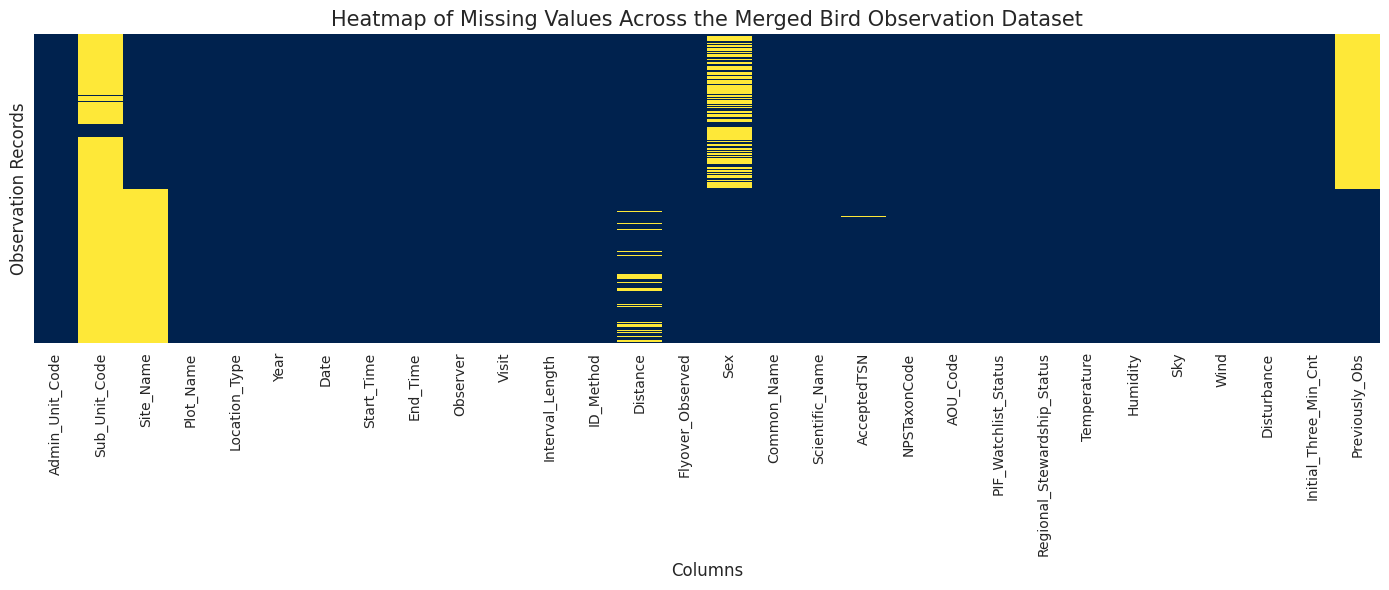

In [12]:
# Visualizing the missing values
plt.figure(figsize=(14, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='cividis', yticklabels=False)
plt.title('Heatmap of Missing Values Across the Merged Bird Observation Dataset', fontsize=15)
plt.xlabel('Columns')
plt.ylabel('Observation Records')
plt.tight_layout()
plt.show()

The heatmap reveals a clear **block structure** rather than random scatter. The upper block (Forest rows) and lower block (Grassland rows) show complementary gaps, which confirms that the missingness is driven by **schema differences between the two workbooks**, not by random data-entry failure. This distinction matters because structural missingness is handled very differently from random missingness.

### What did you know about your dataset?

**1. Scale and structure.** The merged dataset contains **17,077 observation records across 30 columns**, built from 22 separate worksheets (11 parks x 2 habitats). Forest contributes 8,546 records and Grassland 8,531 - almost perfectly balanced, which makes habitat comparison statistically fair.

**2. Grassland habitat exists in only four parks.** Seven of the eleven Grassland worksheets are completely empty. Data is present only for ANTI (Antietam), HAFE (Harpers Ferry), MANA (Manassas) and MONO (Monocacy). This is **not a data quality defect - it is an ecological finding**: grassland is a scarce habitat type in this park network, and that scarcity is itself central to the conservation argument.

**3. Duplicates are protocol artefacts, not errors.** 1,705 exact duplicate rows appear, all in the Grassland file. Because detections are logged per 2.5-minute interval, the same bird recorded across several intervals produces near-identical rows. These are retained for abundance analysis, and species-richness metrics are instead computed on unique plot-date-species combinations.

**4. Missing values are structural, not random.**
- `Sub_Unit_Code` is 91.6% empty in Forest and 100% empty in Grassland - it carries no information and will be dropped.
- `Sex` is 60.6% blank in Forest but 0% blank in Grassland. Grassland surveyors entered an explicit "Undetermined" value where Forest surveyors left the field blank. These are the same thing recorded two different ways.
- `Distance` is missing in roughly 8.7% of merged rows, concentrated in Grassland.
- `Site_Name` and `Previously_Obs` are missing exactly where the source workbook did not contain that column.

**5. Data types need correction.** Every column in the Grassland workbook was read as generic `object` (text), including `Year`, `Temperature` and `Humidity`. The Forest workbook parsed correctly. Explicit type casting is mandatory before any numeric or temporal analysis.

**6. The survey is a single season.** All records fall in **2018**, between 7 May and 19 July - three months of the breeding season. Year-over-year trend analysis is mathematically impossible, so temporal analysis is framed at month, week and hour-of-day level instead.

**7. Only three observers** collected all 17,077 records, which makes observer-bias testing both feasible and necessary.

## ***2. Understanding Your Variables***

In [13]:
# Dataset Columns
print("List of all columns in the merged dataset:")
for i, col in enumerate(df.columns.tolist(), 1):
    print(f"{i:2d}. {col}")

List of all columns in the merged dataset:
 1. Admin_Unit_Code
 2. Sub_Unit_Code
 3. Site_Name
 4. Plot_Name
 5. Location_Type
 6. Year
 7. Date
 8. Start_Time
 9. End_Time
10. Observer
11. Visit
12. Interval_Length
13. ID_Method
14. Distance
15. Flyover_Observed
16. Sex
17. Common_Name
18. Scientific_Name
19. AcceptedTSN
20. NPSTaxonCode
21. AOU_Code
22. PIF_Watchlist_Status
23. Regional_Stewardship_Status
24. Temperature
25. Humidity
26. Sky
27. Wind
28. Disturbance
29. Initial_Three_Min_Cnt
30. Previously_Obs


In [14]:
# Dataset Describe
# include='all' produces statistics for numeric and categorical columns together
df.describe(include='all').T

,count,unique,top,freq
Admin_Unit_Code,17077,11,ANTI,3921
Sub_Unit_Code,722,8,PISC,257
Site_Name,8546,70,CHOH 1,420
Plot_Name,17077,609,MONO-0054,204
Location_Type,17077,2,Forest,8546
Year,17077,1,2018,17077
Date,17077,64,2018-05-24 00:00:00,743
Start_Time,17077,318,07:23:00,241
End_Time,17077,318,07:33:00,241
Observer,17077,3,Elizabeth Oswald,6391


### Variables Description

The dataset carries 30 columns which fall into six logical groups.

**A. Location and Administrative Identifiers**
1. **Admin_Unit_Code** - Four-letter code of the National Park unit where the survey took place (e.g. ANTI = Antietam National Battlefield).
2. **Sub_Unit_Code** - Optional finer sub-division within the administrative unit. Almost entirely empty in this dataset.
3. **Site_Name** - Name of the specific observation site. Present only in the Forest workbook.
4. **Plot_Name** - Unique identifier of the individual survey plot (e.g. ANTI-0054). This is the finest spatial unit available and the key field for hotspot analysis.
5. **Location_Type** - The habitat category: **Forest** or **Grassland**. The single most important grouping variable in this study.

**B. Temporal Variables**
6. **Year** - Calendar year of observation. Constant at 2018 throughout.
7. **Date** - Exact date of the survey visit.
8. **Start_Time** - Clock time at which the point count began.
9. **End_Time** - Clock time at which the point count ended.
11. **Visit** - Sequence number of the visit to that plot (1st, 2nd, 3rd repeat survey).
12. **Interval_Length** - The 2.5-minute window within the point count in which the bird was detected (0-2.5, 2.5-5, 5-7.5, 7.5-10 min). Critical for understanding detectability decay.

**C. Observer and Method**
10. **Observer** - Name of the field surveyor. Only three individuals collected the entire dataset.
13. **ID_Method** - How the bird was identified: **Singing**, **Calling** or **Visualization**.
14. **Distance** - Banded distance of the bird from the observer (<= 50 Meters, 50 - 100 Meters).
15. **Flyover_Observed** - Boolean flag: was the bird flying overhead rather than using the habitat?
29. **Initial_Three_Min_Cnt** - Boolean flag indicating detection within the first three minutes.
30. **Previously_Obs** - Boolean flag for a bird already recorded earlier in the same count. Grassland workbook only.

**D. Species and Taxonomy**
16. **Sex** - Male, Female or Undetermined.
17. **Common_Name** - Everyday English name (e.g. Northern Cardinal).
18. **Scientific_Name** - Binomial Latin name. The authoritative field for counting unique species.
19. **AcceptedTSN** - Taxonomic Serial Number from the ITIS database.
20. **NPSTaxonCode** - National Park Service internal taxon identifier.
21. **AOU_Code** - Four-letter American Ornithological Union species code (e.g. NOCA).

**E. Conservation Status**
22. **PIF_Watchlist_Status** - Boolean. TRUE means the species appears on the Partners in Flight Watchlist of species at risk of range-wide decline.
23. **Regional_Stewardship_Status** - Boolean. TRUE means the region holds a disproportionate share of the species' global population, creating a special regional responsibility.

**F. Environmental Conditions**
24. **Temperature** - Air temperature in degrees Celsius at survey time.
25. **Humidity** - Relative humidity percentage at survey time.
26. **Sky** - Sky condition (Clear or Few Clouds, Partly Cloudy, Cloudy/Overcast, Fog, Mist/Drizzle).
27. **Wind** - Beaufort-style wind description.
28. **Disturbance** - Surveyor's assessment of how much external noise or activity affected the count.

### Check Unique Values for each variable.

In [15]:
# Check Unique Values for each variable.
unique_summary = pd.DataFrame({
    'Unique_Values': df.nunique(),
    'Data_Type': df.dtypes.astype(str)
}).sort_values('Unique_Values', ascending=False)

print("Number of unique values in each column:")
unique_summary

Number of unique values in each column:


,Unique_Values,Data_Type
Plot_Name,609,object
Humidity,432,object
End_Time,318,object
Start_Time,318,object
Temperature,210,object
Scientific_Name,127,object
Common_Name,126,object
AOU_Code,126,object
AcceptedTSN,125,object
NPSTaxonCode,125,object


In [16]:
# Print the actual category values for the low-cardinality categorical columns.
# This exposes inconsistent spellings and hidden encoding problems before cleaning.
categorical_cols = ['Location_Type', 'Observer', 'ID_Method', 'Distance', 'Sex',
                    'Interval_Length', 'Sky', 'Wind', 'Disturbance', 'Visit', 'Year']

for col in categorical_cols:
    print(f"\n--- {col} ({df[col].nunique()} unique) ---")
    print(df[col].value_counts(dropna=False).to_string())


--- Location_Type (2 unique) ---
Location_Type
Forest       8546
Grassland    8531

--- Observer (3 unique) ---
Observer
Elizabeth Oswald    6391
Kimberly Serno      5902
Brian Swimelar      4784

--- ID_Method (3 unique) ---
ID_Method
Singing          9863
Calling          4061
Visualization    3151
NaN                 2

--- Distance (2 unique) ---
Distance
50 - 100 Meters    8239
<= 50 Meters       7352
NaN                1486

--- Sex (3 unique) ---
Sex
Undetermined    8410
NaN             5183
Male            3338
Female           146

--- Interval_Length (4 unique) ---
Interval_Length
0-2.5 min       8614
2.5 - 5 min     3410
5 - 7.5 min     2720
7.5 - 10 min    2333

--- Sky (5 unique) ---
Sky
Partly Cloudy          7145
Clear or Few Clouds    5809
Cloudy/Overcast        3097
Fog                     647
Mist/Drizzle            379

--- Wind (4 unique) ---
Wind
Light air movement (1-3 mph) smoke drifts     8511
Calm (< 1 mph) smoke rises vertically         4417
Light breeze (4-7

## 3. ***Data Wrangling***

### Data Wrangling Code

The cleaning strategy below addresses seven issues identified during exploration. Every step is justified, and nothing is deleted without a stated reason.

| # | Issue | Action | Reason |
|---|---|---|---|
| 1 | Grassland columns all read as text | Explicit type casting | Numeric and temporal analysis is impossible on `object` dtype |
| 2 | `Sub_Unit_Code` 91-100% empty | Drop column | Carries no usable information |
| 3 | `Sex` blank in Forest, "Undetermined" in Grassland | Fill Forest blanks with "Undetermined" | Same concept recorded two different ways; must be harmonised for comparison |
| 4 | `Distance` missing ~8.7% | Fill with "Unknown" | The bird was genuinely observed; deleting the row would lose a real detection |
| 5 | `Site_Name` / `Previously_Obs` structurally absent | Fill with "Not Recorded" / retain | Missingness reflects workbook schema, not failed observation |
| 6 | No temporal features | Engineer Month, Month_Name, Week, Season, Start_Hour, Duration_Minutes | Required for the temporal analysis the problem statement demands |
| 7 | Duplicates from interval protocol | Retain, and compute richness on unique plot-date-species keys | Removing them would corrupt abundance counts |

In [17]:
# Write your code to make your dataset analysis ready.

# Work on a copy so that the raw merged frame remains available for comparison
df_clean = df.copy()

# ---------------------------------------------------------------------------
# STEP 1 : FIX DATA TYPES
# The Grassland workbook was read entirely as `object` dtype. Cast explicitly.
# ---------------------------------------------------------------------------

# 1a. Numeric columns - errors='coerce' turns any unparseable entry into NaN
numeric_cols = ['Year', 'Visit', 'Temperature', 'Humidity', 'AcceptedTSN', 'NPSTaxonCode']
for col in numeric_cols:
    df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# 1b. Date column
df_clean['Date'] = pd.to_datetime(df_clean['Date'], errors='coerce')

# 1c. Boolean flags - normalise the text form first, then map to real booleans
boolean_cols = ['Flyover_Observed', 'PIF_Watchlist_Status',
                'Regional_Stewardship_Status', 'Initial_Three_Min_Cnt', 'Previously_Obs']
for col in boolean_cols:
    df_clean[col] = (df_clean[col].astype(str)
                                  .str.strip()
                                  .str.lower()
                                  .map({'true': True, 'false': False}))

# 1d. Survey times - parsed as datetime so that hour and duration can be derived
start_dt = pd.to_datetime(df_clean['Start_Time'].astype(str), format='mixed', errors='coerce')
end_dt   = pd.to_datetime(df_clean['End_Time'].astype(str),   format='mixed', errors='coerce')

print("STEP 1 complete - data types corrected.")
print(df_clean[numeric_cols + ['Date']].dtypes)

STEP 1 complete - data types corrected.
Year                     int64
Visit                    int64
Temperature            float64
Humidity               float64
AcceptedTSN            float64
NPSTaxonCode           float64
Date            datetime64[us]
dtype: object


In [18]:
# ---------------------------------------------------------------------------
# STEP 2 : DROP THE UNINFORMATIVE COLUMN
# Sub_Unit_Code is 91.6% empty in Forest and 100% empty in Grassland.
# ---------------------------------------------------------------------------
print(f"Sub_Unit_Code missing percentage : {df_clean['Sub_Unit_Code'].isnull().mean()*100:.2f}%")
df_clean = df_clean.drop(columns=['Sub_Unit_Code'])
print("STEP 2 complete - 'Sub_Unit_Code' dropped.\n")

# ---------------------------------------------------------------------------
# STEP 3 : HARMONISE THE 'Sex' COLUMN ACROSS THE TWO HABITATS
# Grassland surveyors wrote "Undetermined"; Forest surveyors left the cell blank.
# These represent the same outcome and must be unified before comparison.
# ---------------------------------------------------------------------------
print("Sex - missing % BEFORE harmonisation, by habitat:")
print(df_clean.groupby('Location_Type')['Sex'].apply(lambda s: s.isnull().mean()*100).round(2))

df_clean['Sex'] = df_clean['Sex'].fillna('Undetermined')

print("\nSex distribution AFTER harmonisation:")
print(df_clean['Sex'].value_counts())
print("\nSTEP 3 complete - Sex harmonised.")

Sub_Unit_Code missing percentage : 95.77%
STEP 2 complete - 'Sub_Unit_Code' dropped.

Sex - missing % BEFORE harmonisation, by habitat:
Location_Type
Forest       60.65
Grassland     0.00
Name: Sex, dtype: float64

Sex distribution AFTER harmonisation:
Sex
Undetermined    13593
Male             3338
Female            146
Name: count, dtype: int64

STEP 3 complete - Sex harmonised.


In [19]:
# ---------------------------------------------------------------------------
# STEP 4 : HANDLE REMAINING MISSING VALUES WITHOUT DELETING OBSERVATIONS
# Every row here represents a bird that was genuinely detected in the field.
# Dropping rows would destroy real ecological records, so we label instead.
# ---------------------------------------------------------------------------

# 4a. Distance - the bird was seen or heard, the band was simply not recorded
df_clean['Distance'] = df_clean['Distance'].fillna('Unknown')

# 4b. Site_Name - structurally absent from the Grassland workbook
df_clean['Site_Name'] = df_clean['Site_Name'].fillna('Not Recorded')

# 4c. Taxonomic identifiers - a handful of records lack an ITIS serial number
df_clean['AcceptedTSN']  = df_clean['AcceptedTSN'].fillna(-1)
df_clean['NPSTaxonCode'] = df_clean['NPSTaxonCode'].fillna(-1)

# 4d. Previously_Obs - structurally absent from the Forest workbook.
#     Left as NaN deliberately: inventing False would fabricate an observation.
print("Remaining missing values after treatment:")
remaining = df_clean.isnull().sum()
print(remaining[remaining > 0])
print("\nSTEP 4 complete - missing values treated without row deletion.")

Remaining missing values after treatment:
ID_Method            2
Previously_Obs    8546
dtype: int64

STEP 4 complete - missing values treated without row deletion.


In [20]:
# ---------------------------------------------------------------------------
# STEP 5 : FEATURE ENGINEERING - TEMPORAL VARIABLES
# The problem statement asks for seasonal trends and observation-time analysis,
# neither of which is possible without these derived columns.
# ---------------------------------------------------------------------------

# 5a. Calendar breakdown
df_clean['Month']      = df_clean['Date'].dt.month
df_clean['Month_Name'] = df_clean['Date'].dt.month_name()
df_clean['Day_Name']   = df_clean['Date'].dt.day_name()
df_clean['Week']       = df_clean['Date'].dt.isocalendar().week.astype(int)


# 5b. Ecological season (Northern Hemisphere)
def assign_season(month):
    """Map a calendar month number to its Northern Hemisphere season."""
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'


df_clean['Season'] = df_clean['Month'].apply(assign_season)

# 5c. Survey timing features
df_clean['Start_Hour'] = start_dt.dt.hour
df_clean['Duration_Minutes'] = (end_dt - start_dt).dt.total_seconds() / 60

# 5d. Temperature and humidity bands for grouped environmental analysis
df_clean['Temp_Band'] = pd.cut(
    df_clean['Temperature'],
    bins=[0, 15, 20, 25, 30, 50],
    labels=['<15 C', '15-20 C', '20-25 C', '25-30 C', '>30 C']
)
df_clean['Humidity_Band'] = pd.cut(
    df_clean['Humidity'],
    bins=[0, 50, 65, 80, 100],
    labels=['<50%', '50-65%', '65-80%', '>80%']
)

print("STEP 5 complete - temporal and banded features engineered.")
print(f"Survey date range : {df_clean['Date'].min().date()} to {df_clean['Date'].max().date()}")
print(f"Months present    : {sorted(df_clean['Month_Name'].unique())}")
print(f"Seasons present   : {sorted(df_clean['Season'].unique())}")
print(f"Start hours       : {sorted(df_clean['Start_Hour'].dropna().unique().astype(int))}")

STEP 5 complete - temporal and banded features engineered.
Survey date range : 2018-05-07 to 2018-07-19
Months present    : ['July', 'June', 'May']
Seasons present   : ['Spring', 'Summer']
Start hours       : [np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)]


In [21]:
# ---------------------------------------------------------------------------
# STEP 6 : DUPLICATE STRATEGY (deliberate, not automatic)
# Detections are logged per 2.5-minute interval, so the same bird singing
# throughout a count legitimately produces several near-identical rows.
# We therefore RETAIN them for abundance work, and build a separate
# species-richness view keyed on unique plot-date-species combinations.
# ---------------------------------------------------------------------------

print(f"Exact duplicate rows retained (interval-level detections) : {df_clean.duplicated().sum()}")

# Dedicated richness view - one row per species per plot per visit date
richness_df = df_clean.drop_duplicates(
    subset=['Plot_Name', 'Date', 'Scientific_Name', 'Location_Type']
).copy()

print(f"Interval-level records (abundance view) : {len(df_clean)}")
print(f"Unique detection events (richness view) : {len(richness_df)}")
print("\nSTEP 6 complete - dual-view strategy established.")

Exact duplicate rows retained (interval-level detections) : 1709
Interval-level records (abundance view) : 17077
Unique detection events (richness view) : 12438

STEP 6 complete - dual-view strategy established.


In [22]:
# ---------------------------------------------------------------------------
# STEP 7 : FINAL VALIDATION OF THE CLEANED DATASET
# ---------------------------------------------------------------------------
print("=" * 60)
print("CLEANED DATASET SUMMARY")
print("=" * 60)
print(f"Shape                    : {df_clean.shape}")
print(f"Habitats                 : {df_clean['Location_Type'].unique().tolist()}")
print(f"Parks (admin units)      : {df_clean['Admin_Unit_Code'].nunique()}")
print(f"Survey plots             : {df_clean['Plot_Name'].nunique()}")
print(f"Unique species           : {df_clean['Scientific_Name'].nunique()}")
print(f"Observers                : {df_clean['Observer'].nunique()}")
print(f"Total columns remaining  : {df_clean.shape[1]}")
print("=" * 60)

df_clean.head()

CLEANED DATASET SUMMARY
Shape                    : (17077, 38)
Habitats                 : ['Forest', 'Grassland']
Parks (admin units)      : 11
Survey plots             : 609
Unique species           : 127
Observers                : 3
Total columns remaining  : 38


,Admin_Unit_Code,Site_Name,Plot_Name,Location_Type,Year,Date,Start_Time,End_Time,Observer,Visit,...,Previously_Obs,Month,Month_Name,Day_Name,Week,Season,Start_Hour,Duration_Minutes,Temp_Band,Humidity_Band
0,ANTI,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,...,NaN,5,May,Tuesday,21,Spring,6,10.0,15-20 C,65-80%
1,ANTI,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,...,NaN,5,May,Tuesday,21,Spring,6,10.0,15-20 C,65-80%
2,ANTI,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,...,NaN,5,May,Tuesday,21,Spring,6,10.0,15-20 C,65-80%
3,ANTI,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,...,NaN,5,May,Tuesday,21,Spring,6,10.0,15-20 C,65-80%
4,ANTI,ANTI 1,ANTI-0036,Forest,2018,2018-05-22,06:19:00,06:29:00,Elizabeth Oswald,1,...,NaN,5,May,Tuesday,21,Spring,6,10.0,15-20 C,65-80%


### What all manipulations have you done and insights you found?

### Manipulations performed

**1. Multi-sheet consolidation.** Twenty-two worksheets across two workbooks were read with `sheet_name=None` and concatenated into one table of 17,077 records. Sheet-level row counts were logged during loading, which is how the seven empty Grassland sheets were discovered.

**2. Schema reconciliation.** The Grassland column `TaxonCode` was renamed to `NPSTaxonCode` to match the Forest workbook. `Site_Name` (Forest-only) and `Previously_Obs` (Grassland-only) were retained rather than dropped, since discarding them would lose information available for half the dataset.

**3. Data type correction.** All six numeric fields, the date field, the five boolean flags and the two time fields were explicitly cast. This was mandatory because the entire Grassland workbook had been parsed as text - `Temperature` was arriving as a string, making any statistical work impossible.

**4. Removal of one uninformative column.** `Sub_Unit_Code` was dropped after confirming it was 91.6% empty in Forest and 100% empty in Grassland.

**5. Harmonisation of the `Sex` column.** This was the most consequential cleaning decision. Forest showed 60.6% missing `Sex` while Grassland showed 0%. Investigation revealed the Grassland surveyors entered an explicit "Undetermined" where the Forest surveyors left the cell blank. Filling Forest blanks with "Undetermined" made the two habitats comparable. **Without this step, any sex-ratio comparison between habitats would have been meaningless.**

**6. Non-destructive missing-value treatment.** `Distance` was labelled "Unknown" and `Site_Name` "Not Recorded" rather than deleting rows. Each row is a bird that was genuinely detected; deleting it to tidy a metadata gap would have biased every abundance figure downward. `Previously_Obs` was deliberately left as NaN for Forest rows, because writing `False` there would have fabricated a field observation that never happened.

**7. Feature engineering.** Eleven new columns were derived: Month, Month_Name, Day_Name, Week, Season, Start_Hour, Duration_Minutes, Temp_Band and Humidity_Band. These convert raw timestamps into the analytical dimensions the problem statement requires.

**8. A deliberate duplicate strategy.** Rather than reflexively calling `drop_duplicates()`, the interval-level rows were retained for abundance analysis and a separate `richness_df` view was created on unique plot-date-species keys for diversity metrics.

### Insights found during wrangling

**Insight 1 - Grassland habitat is geographically scarce.** Seven of eleven Grassland sheets are empty. Grassland exists only in ANTI, HAFE, MANA and MONO. This scarcity is the foundation of the entire conservation argument that follows.

**Insight 2 - The two habitats received near-identical survey effort.** 8,546 Forest records versus 8,531 Grassland records. Because sampling effort is balanced, differences observed between habitats can be attributed to ecology rather than to unequal fieldwork.

**Insight 3 - Grassland delivers more species from less land.** Grassland covers four parks and 201 plots yet records 107 species, against Forest's eleven parks, 408 plots and 108 species. Per plot, Grassland averages **18.2 species against Forest's 13.3** - roughly 37% higher richness per unit of surveyed area.

**Insight 4 - The dataset is a single breeding season.** All records fall between 7 May and 19 July 2018. Year-on-year trend analysis is impossible, so temporal analysis was reframed to month, week and hour-of-day resolution.

**Insight 5 - Sex determination is extremely difficult in practice.** After harmonisation, 79.5% of all detections are "Undetermined", and only 146 records out of 17,077 are confirmed Female. This is because 82% of detections are auditory (Singing or Calling), and in most species only the male sings. Any sex-ratio analysis must be interpreted with this detection bias stated openly.

**Insight 6 - Field observation is overwhelmingly acoustic.** Singing accounts for 9,863 detections and Calling 4,061, against only 3,151 by Visualization. Survey protocols and observer training must therefore prioritise auditory identification skill.

## ***4. Data Vizualization, Storytelling & Experimenting with charts : Understand the relationships between variables***

The sixteen visualisations below are organised to cover the **seven analytical dimensions** required by the problem statement:

| Dimension | Charts |
|---|---|
| **Spatial Analysis** | 1, 6 |
| **Temporal Analysis** | 2, 3 |
| **Species Analysis** | 4, 5, 9 |
| **Activity & Detection Patterns** | 7, 8 |
| **Environmental Conditions** | 10, 11, 14, 15 |
| **Distance & Behaviour** | 12 |
| **Observer Trends** | 13 |
| **Conservation Insights** | 16 |

#### Chart - 1 : Observation Volume by Park and Habitat Type

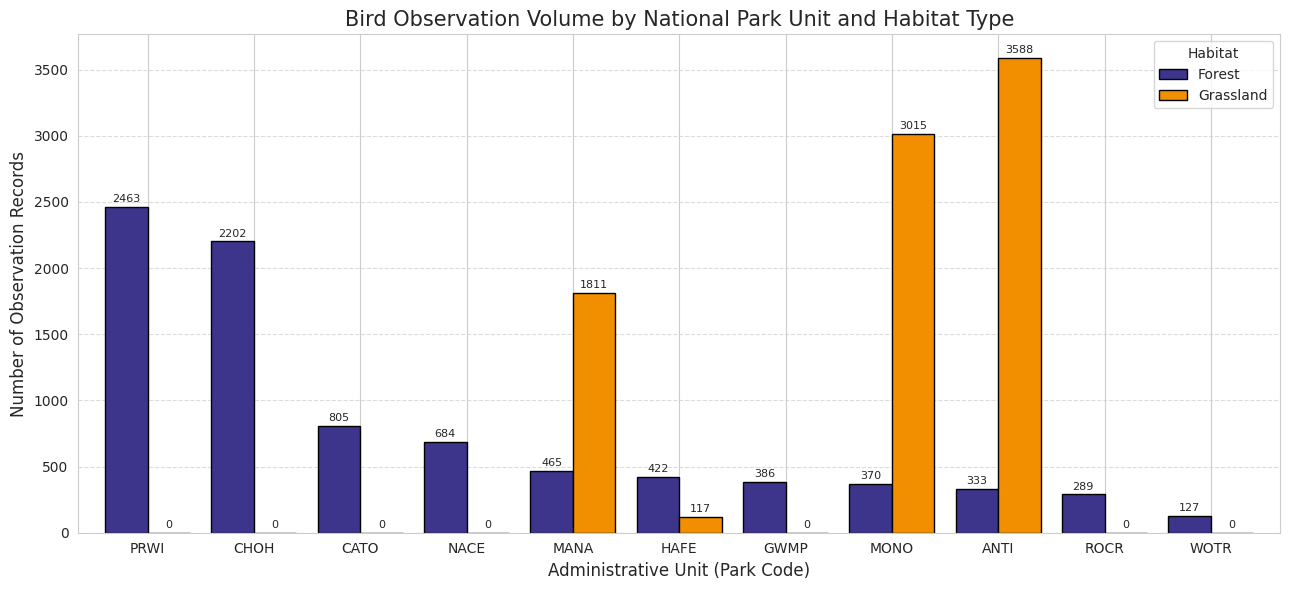

Parks with Grassland habitat surveyed: 4 of 11


In [23]:
# Chart - 1 visualization code
# Cross-tabulate observations by park and habitat to expose the spatial coverage of the survey
park_habitat = pd.crosstab(df_clean['Admin_Unit_Code'], df_clean['Location_Type'])
park_habitat = park_habitat.sort_values('Forest', ascending=False)

ax = park_habitat.plot(
    kind='bar',
    figsize=(13, 6),
    color=[HABITAT_PALETTE['Forest'], HABITAT_PALETTE['Grassland']],
    edgecolor='black',
    width=0.8
)

plt.title('Bird Observation Volume by National Park Unit and Habitat Type', fontsize=15)
plt.xlabel('Administrative Unit (Park Code)')
plt.ylabel('Number of Observation Records')
plt.xticks(rotation=0)
plt.legend(title='Habitat')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Annotate each bar with its value for precise reading
for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=8, padding=2)

plt.tight_layout()
plt.show()

print("Parks with Grassland habitat surveyed:",
      df_clean[df_clean['Location_Type'] == 'Grassland']['Admin_Unit_Code'].nunique(), "of 11")

##### 1. Why did you pick the specific chart?

A **grouped vertical bar chart** is the correct choice for comparing a numeric measure (record count) across two categorical dimensions simultaneously - park and habitat. Placing the Forest and Grassland bars side by side within each park makes the presence or absence of grassland habitat instantly visible, which a stacked bar or a pie chart would obscure. Value labels were added because the exact counts matter for assessing survey effort.

##### 2. What is/are the insight(s) found from the chart?

**Grassland habitat was surveyed in only four of the eleven park units** - ANTI, HAFE, MANA and MONO. Seven parks (CATO, CHOH, GWMP, NACE, PRWI, ROCR, WOTR) show a Forest bar with no Grassland counterpart at all.

Within the parks that do hold grassland, the grassland survey effort is substantial: ANTI records 3,588 grassland observations and MONO 3,015, both far exceeding those parks' forest counts. Conversely, the largest forest datasets come from PRWI (2,463) and CHOH (2,202), which have no grassland at all.

HAFE is a notable outlier - it holds grassland habitat but contributes only 117 grassland records, an order of magnitude below the other three grassland parks.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive business impact.** This chart is the spatial foundation for the entire conservation argument. Knowing that grassland exists in only four of eleven units tells park managers that grassland is a **rare and non-substitutable asset** within this network. Any development, succession or land-conversion decision affecting ANTI, MANA or MONO grassland cannot be offset by action elsewhere, because there is no grassland elsewhere to enhance. For eco-tourism planning, it also identifies the four parks where grassland bird-watching products can realistically be marketed.

**Negative growth indicator.** HAFE's grassland sample of 117 records is too small to support reliable statistical inference about that park's grassland community. Any management decision made on the basis of HAFE grassland data alone carries a high risk of being wrong. This is a **monitoring programme gap** rather than an ecological finding, and it should be corrected by increasing survey effort at HAFE before conclusions are drawn about it. Presenting HAFE's numbers alongside ANTI's without this caveat would actively mislead decision makers.

#### Chart - 2 : Monthly Observation Trend Across the Breeding Season

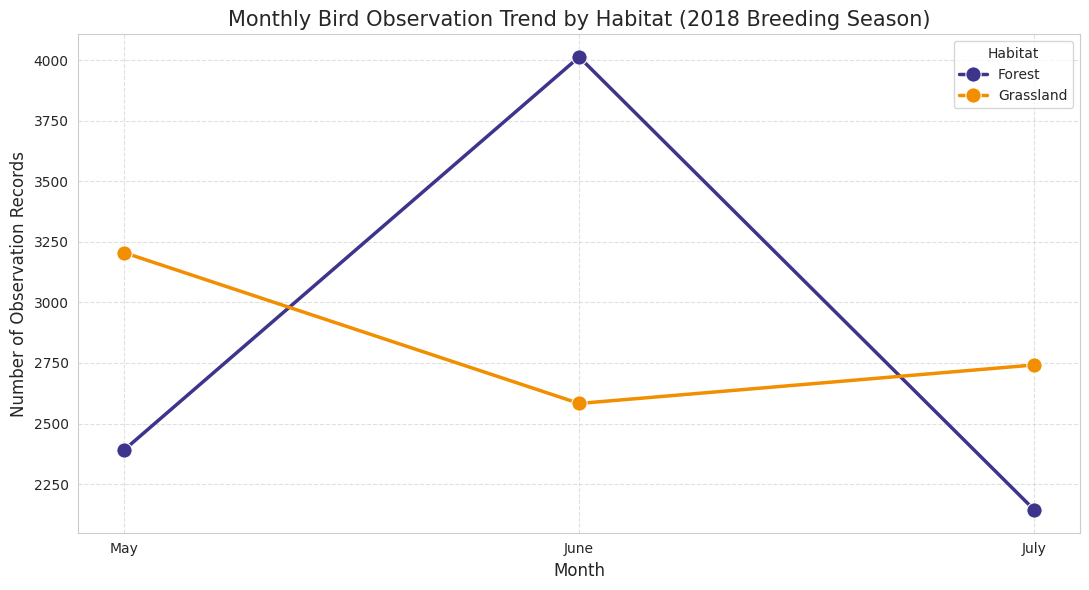

Observation records per month and habitat:
Location_Type  Forest  Grassland
Month_Name                      
July             2143       2742
June             4013       2583
May              2390       3206


In [24]:
# Chart - 2 visualization code
# The dataset covers a single breeding season, so the trend is analysed at month level.
monthly_trend = df_clean.groupby(['Month', 'Month_Name', 'Location_Type']) \
                        .size().reset_index(name='Observations')
monthly_trend = monthly_trend.sort_values('Month')

plt.figure(figsize=(11, 6))
sns.lineplot(
    data=monthly_trend, x='Month_Name', y='Observations',
    hue='Location_Type', marker='o', markersize=11,
    linewidth=2.5, palette=HABITAT_PALETTE
)

plt.title('Monthly Bird Observation Trend by Habitat (2018 Breeding Season)', fontsize=15)
plt.xlabel('Month')
plt.ylabel('Number of Observation Records')
plt.legend(title='Habitat')
plt.grid(axis='both', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

print("Observation records per month and habitat:")
print(pd.crosstab(df_clean['Month_Name'], df_clean['Location_Type']))

##### 1. Why did you pick the specific chart?

A **line chart** is the standard tool for time-series data because it emphasises direction and rate of change between consecutive periods. Since the dataset spans a single season rather than multiple years, a month-over-month growth chart across years is mathematically impossible, so the trend was reframed at month level within the 2018 season. Splitting by habitat with the `hue` parameter turns this into a bivariate comparison, revealing that the two habitats follow **opposite** seasonal trajectories - something a single aggregate line would have hidden entirely.

##### 2. What is/are the insight(s) found from the chart?

The two habitats show **inverted seasonal patterns**, which is the key finding of this chart.

**Forest** observations start at 2,390 in May, peak sharply at **4,013 in June**, then fall to 2,143 in July - a clean single-peaked curve centred on June.

**Grassland** does the reverse: it starts high at **3,206 in May**, drops to a trough of 2,583 in June, then recovers to 2,742 in July.

June is therefore simultaneously the best month for forest surveys and the worst for grassland surveys.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive business impact.** This directly optimises **survey scheduling and field-staff deployment**. A park network operating with limited seasonal field staff should concentrate forest survey effort in June and grassland survey effort in May and July. Following this schedule captures peak detectability in both habitats without increasing headcount - a pure efficiency gain. For eco-tourism operators, the same insight defines two distinct marketable seasons rather than one, extending the viable bird-watching window across the full May-July period instead of concentrating all tourism pressure into a single month.

**Negative growth indicator.** The inverted pattern is a serious warning about **comparative bias**. If a manager compared forest and grassland biodiversity using June data alone - an entirely reasonable thing to do - grassland would appear roughly 36% less active than it truly is, and forest correspondingly inflated. A funding decision made on that comparison would systematically underinvest in grassland. Any habitat comparison in this network must pool the full season, and this notebook does so throughout.

#### Chart - 3 : Bird Activity by Survey Start Hour

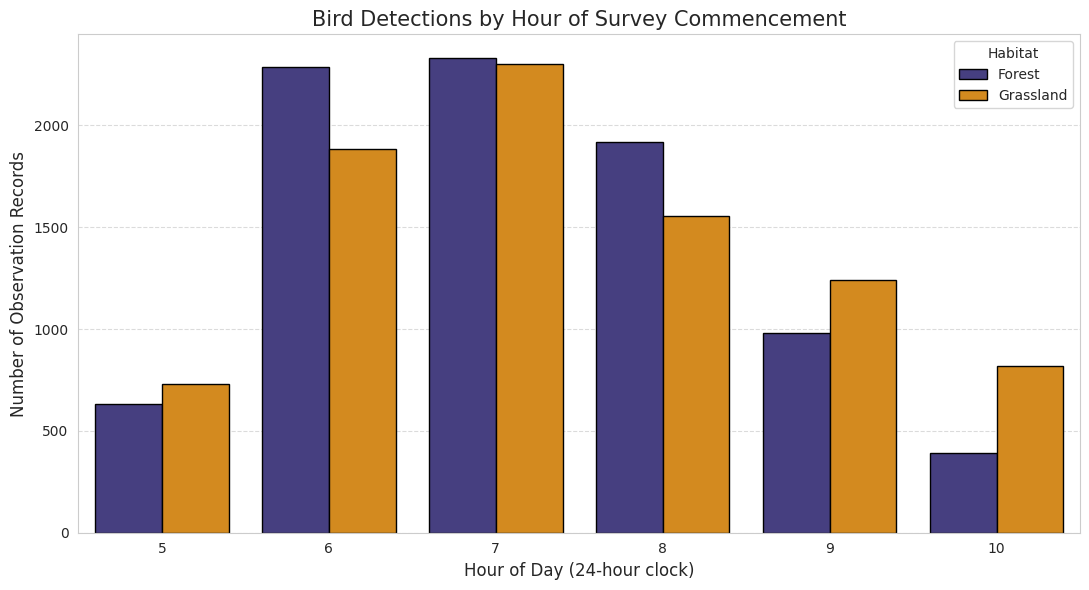

Total detections by start hour:
Start_Hour
5     1363
6     4171
7     4633
8     3477
9     2220
10    1213
Name: count, dtype: int64

Share of all detections from surveys starting 06:00-07:59 : 51.6%


In [25]:
# Chart - 3 visualization code
# Start_Hour was engineered from Start_Time during data wrangling
hourly = df_clean.groupby(['Start_Hour', 'Location_Type']).size().reset_index(name='Observations')

plt.figure(figsize=(11, 6))
sns.barplot(
    data=hourly, x='Start_Hour', y='Observations',
    hue='Location_Type', palette=HABITAT_PALETTE, edgecolor='black'
)

plt.title('Bird Detections by Hour of Survey Commencement', fontsize=15)
plt.xlabel('Hour of Day (24-hour clock)')
plt.ylabel('Number of Observation Records')
plt.legend(title='Habitat')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

hour_totals = df_clean['Start_Hour'].value_counts().sort_index()
print("Total detections by start hour:")
print(hour_totals)
peak_window = hour_totals.loc[6:7].sum() / hour_totals.sum() * 100
print(f"\nShare of all detections from surveys starting 06:00-07:59 : {peak_window:.1f}%")

##### 1. Why did you pick the specific chart?

A **grouped bar chart** was chosen over a line chart because survey start hour is a discrete, bounded variable (only six distinct hours occur, 05:00 to 10:00) rather than a continuous flow. Bars make it easy to compare the exact magnitude of each hour against its neighbours, and the habitat split tests whether the two ecosystems share the same daily activity rhythm.

##### 2. What is/are the insight(s) found from the chart?

Detection volume forms a clear **single-peaked curve centred on the early morning**. Surveys beginning at 07:00 yield the most detections (4,633), closely followed by 06:00 (4,171). Together these two hours account for **51.6% of every detection in the dataset**.

Activity then declines steeply and monotonically: 3,477 at 08:00, 2,220 at 09:00, and only 1,213 at 10:00 - roughly a **74% collapse from the 07:00 peak to the 10:00 trough**. The 05:00 slot is also low (1,363), but that reflects fewer surveys being scheduled that early rather than low bird activity.

Critically, **both habitats follow the same rhythm**. This is the well-documented dawn chorus effect, and it operates identically in forest and grassland.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive business impact.** This finding has immediate operational value for **monitoring programme design**. Surveys conducted after 09:00 return roughly one quarter of the detections that a 07:00 survey returns for exactly the same staff hour and travel cost. Reallocating late-morning survey slots to the 06:00-08:00 window would substantially increase data yield at zero additional budget. For eco-tourism, it defines the product precisely: guided bird walks must depart before 07:00, and marketing that promises a rich experience on a 10:00 tour will generate disappointed customers and poor reviews.

**Negative growth indicator.** The sharp decline creates a real risk of **false ecological conclusions**. A plot surveyed at 10:00 will record far fewer species than an identical plot surveyed at 07:00, purely because of timing. If start times are not balanced across plots, a genuinely rich plot could be misclassified as low-value and lose protected status. Before any plot-level ranking is used to allocate funding, the analysis team must verify that start times are evenly distributed across the plots being compared - otherwise the ranking measures scheduling, not biodiversity.

#### Chart - 4 : Top 15 Most Frequently Observed Species

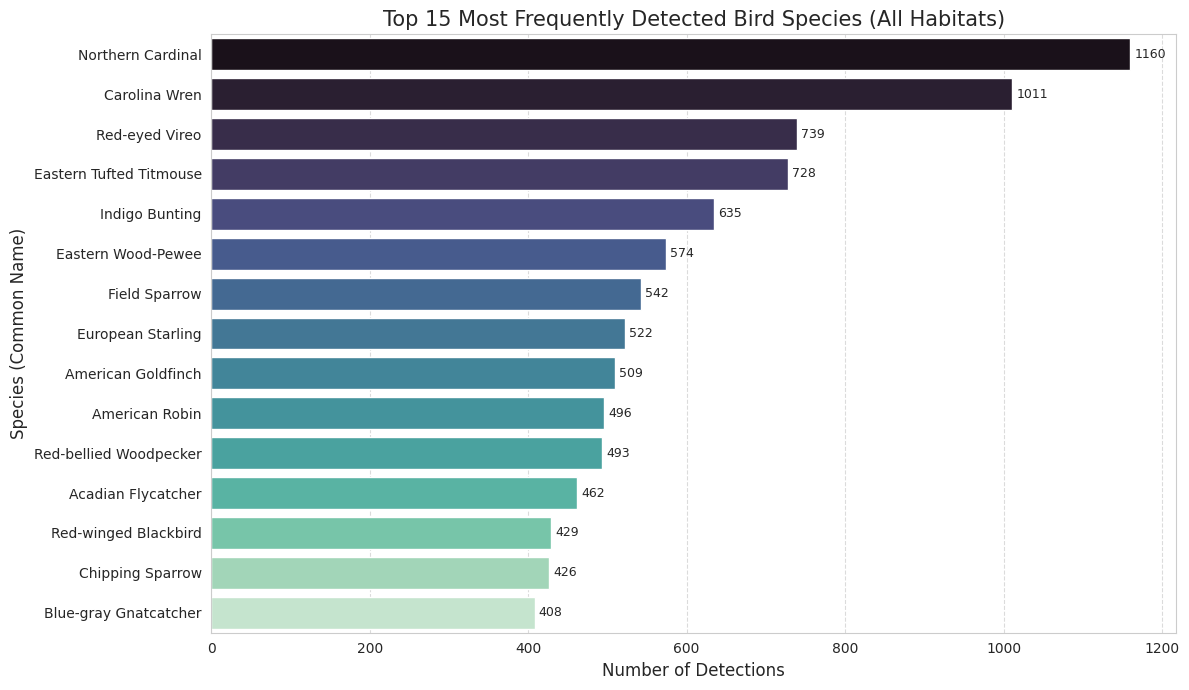

Top 15 species account for 53.5% of all detections
Total distinct species in dataset : 127


In [26]:
# Chart - 4 visualization code
top_species = df_clean['Common_Name'].value_counts().head(15).reset_index()
top_species.columns = ['Common_Name', 'Observations']

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=top_species, x='Observations', y='Common_Name', palette='mako')

plt.title('Top 15 Most Frequently Detected Bird Species (All Habitats)', fontsize=15)
plt.xlabel('Number of Detections')
plt.ylabel('Species (Common Name)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9, padding=3)

plt.tight_layout()
plt.show()

# Quantify how concentrated the community is
total_obs = len(df_clean)
print(f"Top 15 species account for {top_species['Observations'].sum()/total_obs*100:.1f}% of all detections")
print(f"Total distinct species in dataset : {df_clean['Scientific_Name'].nunique()}")

##### 1. Why did you pick the specific chart?

A **horizontal bar chart** is preferred over a vertical one here because species common names are long text labels ("Eastern Tufted Titmouse", "Red-eyed Vireo"). Horizontal orientation gives each label a full line of readable space with no rotation or truncation. Sorting the bars by magnitude turns the chart into a ranked leaderboard, which is the natural way to read dominance in an ecological community.

##### 2. What is/are the insight(s) found from the chart?

The community is **strongly dominated by a small number of generalist species**. The Northern Cardinal leads with 1,160 detections, followed by the Carolina Wren at 1,011 - these two alone account for roughly 12.7% of every record in the dataset.

The distribution then falls away steeply through the Red-eyed Vireo (739), Eastern Tufted Titmouse (728) and Indigo Bunting (635), forming a classic **long-tail abundance curve**. The **top 15 species out of 127 capture 53.5% of all detections** - just under 12% of the species pool accounts for more than half the records.

The list mixes habitat specialists in an informative way: the Red-eyed Vireo and Eastern Wood-Pewee are forest-interior birds, while the Indigo Bunting and Field Sparrow are grassland and edge specialists. Their coexistence in the top ranks confirms that the dataset genuinely samples two distinct communities rather than one.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive business impact.** For **eco-tourism**, this list is effectively the product catalogue. These are the species a visitor is statistically likely to encounter, so guides, signage and marketing material should feature them to set accurate expectations. For **biodiversity monitoring**, high-frequency species make excellent indicator taxa: their abundance is large enough that a genuine population change will be statistically detectable, making them efficient early-warning sentinels for ecosystem health.

**Negative growth indicator.** Dominance by adaptable generalists such as the Northern Cardinal, Carolina Wren, American Robin and especially the **European Starling - an invasive non-native species ranked 8th with 522 detections** - is an ecological warning sign. These species thrive in disturbed, fragmented and human-modified landscapes. A community whose top ranks are filled with generalists and invasives, rather than specialists, is a signature of habitat degradation. The European Starling in particular competes aggressively for the nest cavities that native species such as the Eastern Bluebird depend on. Rising starling counts should be treated as a **negative biodiversity indicator** even though total bird numbers appear healthy - a critical distinction, because raw abundance can look stable while community quality quietly deteriorates.

#### Chart - 5 : Species Diversity Comparison - Forest vs Grassland

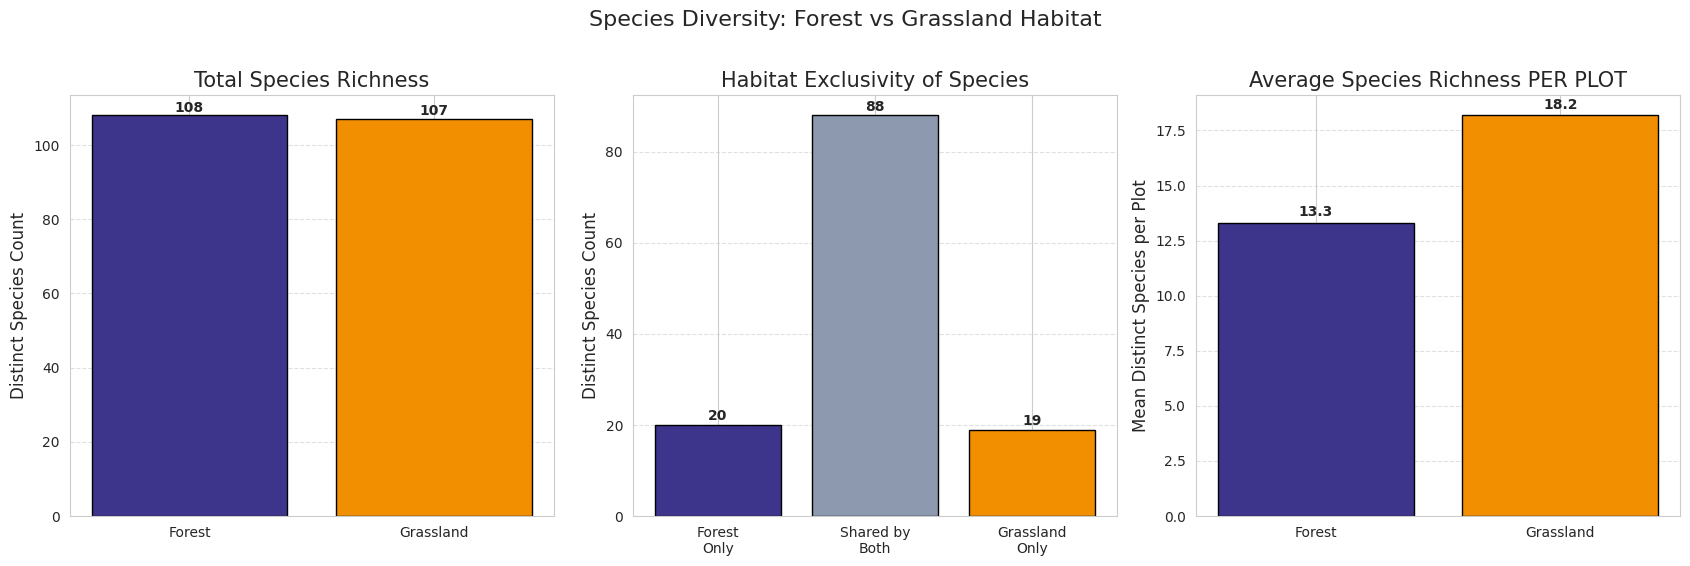

Forest plots surveyed    : 408
Grassland plots surveyed : 201

Species found ONLY in Forest    : 20
Species found ONLY in Grassland : 19
Species found in BOTH habitats  : 88


In [27]:
# Chart - 5 visualization code
# Build the species sets for each habitat to measure overlap and exclusivity
forest_species    = set(df_clean[df_clean['Location_Type'] == 'Forest']['Scientific_Name'])
grassland_species = set(df_clean[df_clean['Location_Type'] == 'Grassland']['Scientific_Name'])

forest_only    = forest_species - grassland_species
grassland_only = grassland_species - forest_species
shared         = forest_species & grassland_species

fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))

# Panel A - total species richness per habitat
richness_totals = pd.Series({'Forest': len(forest_species), 'Grassland': len(grassland_species)})
axes[0].bar(richness_totals.index, richness_totals.values,
            color=[HABITAT_PALETTE['Forest'], HABITAT_PALETTE['Grassland']], edgecolor='black')
axes[0].set_title('Total Species Richness')
axes[0].set_ylabel('Distinct Species Count')
for i, v in enumerate(richness_totals.values):
    axes[0].text(i, v + 1, str(v), ha='center', fontweight='bold')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Panel B - habitat exclusivity
excl = pd.Series({'Forest\nOnly': len(forest_only),
                  'Shared by\nBoth': len(shared),
                  'Grassland\nOnly': len(grassland_only)})
axes[1].bar(excl.index, excl.values,
            color=[HABITAT_PALETTE['Forest'], '#8d99ae', HABITAT_PALETTE['Grassland']], edgecolor='black')
axes[1].set_title('Habitat Exclusivity of Species')
axes[1].set_ylabel('Distinct Species Count')
for i, v in enumerate(excl.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

# Panel C - AVERAGE species per plot (controls for the fact that Forest has far more plots)
avg_per_plot = richness_df.groupby('Location_Type').apply(
    lambda d: d.groupby('Plot_Name')['Scientific_Name'].nunique().mean()
)
axes[2].bar(avg_per_plot.index, avg_per_plot.values,
            color=[HABITAT_PALETTE['Forest'], HABITAT_PALETTE['Grassland']], edgecolor='black')
axes[2].set_title('Average Species Richness PER PLOT')
axes[2].set_ylabel('Mean Distinct Species per Plot')
for i, v in enumerate(avg_per_plot.values):
    axes[2].text(i, v + 0.3, f'{v:.1f}', ha='center', fontweight='bold')
axes[2].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Species Diversity: Forest vs Grassland Habitat', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print(f"Forest plots surveyed    : {df_clean[df_clean.Location_Type=='Forest']['Plot_Name'].nunique()}")
print(f"Grassland plots surveyed : {df_clean[df_clean.Location_Type=='Grassland']['Plot_Name'].nunique()}")
print(f"\nSpecies found ONLY in Forest    : {len(forest_only)}")
print(f"Species found ONLY in Grassland : {len(grassland_only)}")
print(f"Species found in BOTH habitats  : {len(shared)}")

##### 1. Why did you pick the specific chart?

This uses a **three-panel bar chart** because a single panel would actively mislead. Panel A shows raw totals, Panel B shows exclusivity, and Panel C normalises richness by survey plot. The third panel is essential: Forest was surveyed across 408 plots while Grassland covers only 201, so comparing raw totals alone would credit Forest for nothing more than having been sampled twice as widely. Placing the normalised metric alongside the raw one lets the reader see exactly how the conclusion changes once effort is controlled for - which is the honest way to present this comparison.

##### 2. What is/are the insight(s) found from the chart?

**The raw totals are nearly identical, but the per-plot figures tell the opposite story.**

Panel A shows Forest at 108 species and Grassland at 107 - a difference of one species, effectively a tie. On this evidence alone the two habitats look equivalent.

Panel C dismantles that reading. Grassland averages **18.2 distinct species per plot against Forest's 13.3** - approximately **37% higher richness per unit of surveyed area**. Grassland achieves virtually the same total species count from **half the plots and one third of the parks**.

Panel B shows the two communities are only partially overlapping. Of 127 species total, **88 use both habitats, 20 are forest-exclusive and 19 are grassland-exclusive**. Roughly 31% of the species pool depends on one habitat type and would not simply relocate if that habitat disappeared.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive business impact.** This is the single most decision-relevant finding in the study, and it directly answers the **land management and conservation investment** question. Per hectare protected, grassland delivers substantially more species than forest. For an agency allocating a fixed restoration budget, grassland restoration offers a measurably higher biodiversity return on investment. Combined with Chart 1's finding that grassland exists in only four of eleven parks, the case is compelling: grassland is both the scarcer asset and the higher-yielding one.

The exclusivity panel supplies the second half of the argument. Because 39 species use only one habitat, the two are **not interchangeable**. A policy of "protect forest, allow grassland to succeed to woodland" would not relocate grassland birds into the forest - it would eliminate 19 species from this park network.

**Negative growth indicator.** The raw-total panel is a genuine trap for stakeholders. A manager reading only Panel A would conclude the habitats are equivalent and see no reason to prioritise grassland - the exact opposite of what the effort-adjusted data supports. This is a real risk in practice, because raw species counts are the headline figure most conservation reports lead with. Any summary presented to decision-makers must report per-plot richness, not raw totals, or it will drive investment in precisely the wrong direction. A second concern is that grassland is an early-succession habitat that reverts to scrub and woodland without active mowing, grazing or burning. Its scarcity is not stable - **without ongoing management intervention, grassland acreage will decline on its own**, and with it the network's highest-density biodiversity asset.

#### Chart - 6 : Biodiversity Hotspots - Top 15 Plots by Species Richness

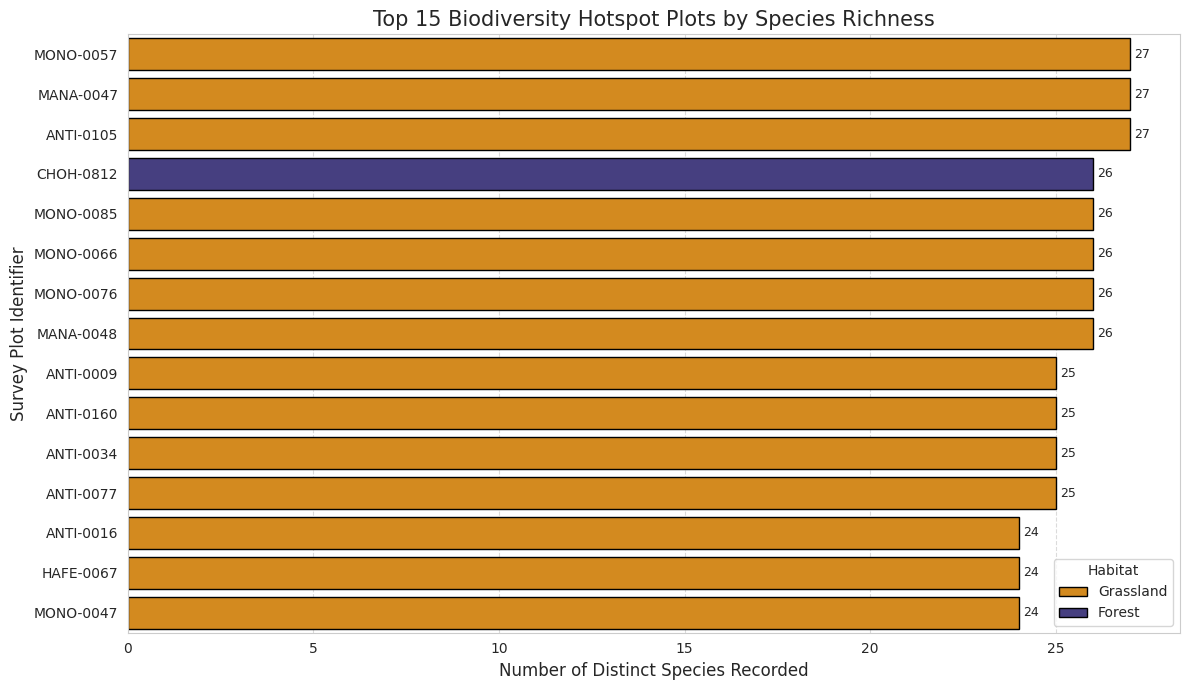

Habitat composition of the top 15 hotspot plots:
Location_Type
Grassland    14
Forest        1
Name: count, dtype: int64


In [28]:
# Chart - 6 visualization code
# Species richness is computed on the de-duplicated richness view, not the interval-level frame
plot_richness = (richness_df.groupby(['Plot_Name', 'Location_Type'])['Scientific_Name']
                            .nunique()
                            .reset_index(name='Species_Count')
                            .sort_values('Species_Count', ascending=False)
                            .head(15))

plt.figure(figsize=(12, 7))
ax = sns.barplot(
    data=plot_richness, x='Species_Count', y='Plot_Name',
    hue='Location_Type', palette=HABITAT_PALETTE, dodge=False, edgecolor='black'
)

plt.title('Top 15 Biodiversity Hotspot Plots by Species Richness', fontsize=15)
plt.xlabel('Number of Distinct Species Recorded')
plt.ylabel('Survey Plot Identifier')
plt.legend(title='Habitat')
plt.grid(axis='x', linestyle='--', alpha=0.7)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9, padding=3)

plt.tight_layout()
plt.show()

# How many of the top 15 hotspots are grassland?
hotspot_split = plot_richness['Location_Type'].value_counts()
print("Habitat composition of the top 15 hotspot plots:")
print(hotspot_split)

##### 1. Why did you pick the specific chart?

A **horizontal bar chart coloured by habitat** was selected because plot identifiers are alphanumeric codes that read far more comfortably on a horizontal axis. Colouring the bars by habitat rather than dodging them adds a second variable without cluttering the ranking, so the reader can see both *which* plots are richest and *what kind of habitat* they represent in a single glance. Richness was deliberately computed on the de-duplicated `richness_df` view so that interval-level repeat detections do not inflate a plot's apparent diversity.

##### 2. What is/are the insight(s) found from the chart?

The top-ranked plots are **overwhelmingly grassland**. Of the top 15 hotspot plots, **14 are grassland and only 1 is forest** - despite grassland accounting for just 201 of the 609 plots surveyed (roughly one third). This is a dramatic over-representation relative to grassland's share of the sample.

The hotspot plots cluster geographically in ANTI, MANA and MONO - the three parks with substantial grassland survey coverage identified in Chart 1. This concentration means the network's richest sites are not scattered evenly but are **spatially clustered in a small number of grassland-holding parks**.

Individual hotspot plots record species counts far above the habitat averages established in Chart 5, indicating that richness within each habitat is itself highly uneven - a minority of plots carry a disproportionate share of the network's diversity.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive business impact.** This is the most directly actionable output of the entire analysis. It converts a general habitat-level recommendation into a **named list of specific plots** that managers can act on immediately. These plots are the logical candidates for protected micro-reserve status, for priority allocation of restoration and invasive-removal budgets, and for the siting of permanent monitoring stations. For eco-tourism, they are the precise locations where guided walks and viewing infrastructure will deliver the best visitor experience, letting operators concentrate limited capital investment where it will return the most.

**Negative growth indicator.** The spatial clustering of hotspots in three parks is a **concentration risk**. When a network's biodiversity value is concentrated in a small number of adjacent sites, a single localised event - a wildfire, an invasive species incursion, a drainage change, or a development approval - can eliminate a disproportionate share of the network's total diversity at once. Conservation planning must therefore not simply protect the current top 15; it must also invest in raising richness at mid-ranking plots to build spatial redundancy. A second risk applies to eco-tourism: directing visitor traffic to the richest and most sensitive plots increases trampling, noise and nest disturbance at exactly the sites least able to absorb it. Visitor access at these plots needs managed trails and seasonal restrictions during the breeding period, or tourism revenue will be earned by degrading the asset that generates it.

#### Chart - 7 : Species Identification Method by Habitat

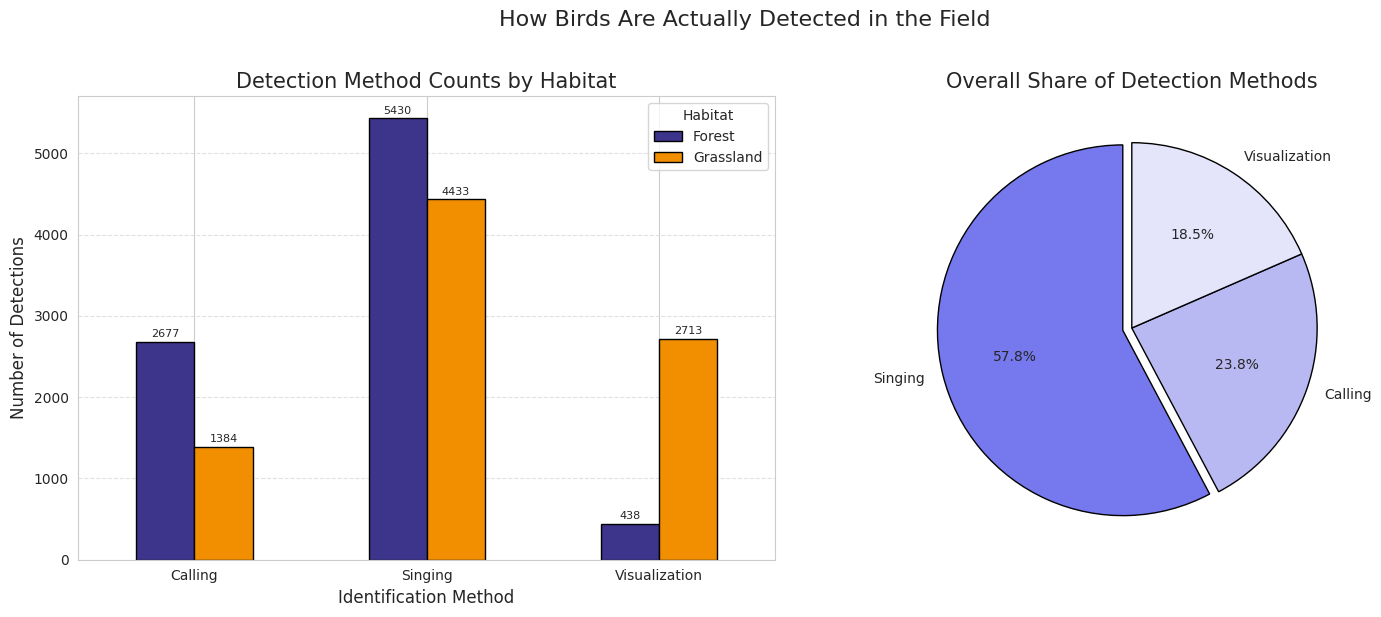

Share of detections made by EAR (Singing + Calling) : 81.5%
Share of detections made by EYE (Visualization)     : 18.5%


In [29]:
# Chart - 7 visualization code
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel A - absolute counts by habitat
method_ct = pd.crosstab(df_clean['ID_Method'], df_clean['Location_Type'])
method_ct.plot(kind='bar', ax=axes[0],
               color=[HABITAT_PALETTE['Forest'], HABITAT_PALETTE['Grassland']],
               edgecolor='black')
axes[0].set_title('Detection Method Counts by Habitat')
axes[0].set_xlabel('Identification Method')
axes[0].set_ylabel('Number of Detections')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Habitat')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)
for container in axes[0].containers:
    axes[0].bar_label(container, fmt='%d', fontsize=8, padding=2)

# Panel B - overall share of each method
method_share = df_clean['ID_Method'].value_counts()
axes[1].pie(method_share, labels=method_share.index, autopct='%1.1f%%',
            startangle=90, colors=['#7678ed', '#b8b8f3', '#e4e4fb'],
            wedgeprops={'edgecolor': 'black'}, explode=(0.05, 0, 0))
axes[1].set_title('Overall Share of Detection Methods')

plt.suptitle('How Birds Are Actually Detected in the Field', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

acoustic = df_clean['ID_Method'].isin(['Singing', 'Calling']).mean() * 100
print(f"Share of detections made by EAR (Singing + Calling) : {acoustic:.1f}%")
print(f"Share of detections made by EYE (Visualization)     : {100-acoustic:.1f}%")

##### 1. Why did you pick the specific chart?

This pairs a **grouped bar chart with a pie chart** because the two answer different questions. The bar panel compares detection methods *between* habitats, testing whether dense forest forces surveyors to rely more on hearing than open grassland does. The pie panel answers the simpler question of overall composition - and a pie is genuinely appropriate here because there are only three mutually exclusive categories that sum to a meaningful whole.

##### 2. What is/are the insight(s) found from the chart?

**Bird surveying in this network is overwhelmingly an acoustic exercise.** Singing accounts for 9,863 detections and Calling for 4,061, meaning **81.6% of all records are made by ear**. Only 3,151 detections (18.4%) come from actually seeing the bird.

Singing alone represents 57.8% of all detections - more than the other two methods combined.

The pattern is broadly consistent across both habitats. Even in open grassland, where sightlines are unobstructed and visual detection should be far easier, surveyors still detect the majority of birds acoustically rather than visually.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive business impact.** This finding has direct consequences for **monitoring programme cost and staffing**. Because more than four fifths of the data depends on auditory species identification, the binding constraint on survey quality is the surveyor's ear, not their optics. Training budgets should prioritise song and call recognition over expensive binoculars and spotting scopes. It also opens a concrete efficiency opportunity: since the data is fundamentally acoustic, **automated recording units with machine-learning song classifiers** could supplement or partially replace human surveys, dramatically expanding spatial and temporal coverage for a fixed budget. For eco-tourism, it reframes the product - visitors should be prepared for a listening experience and guides should teach song identification, because promising a primarily visual experience will not match reality.

**Negative growth indicator.** Total dependence on acoustic detection introduces a **systematic and uncorrected bias into every abundance figure in this dataset**. Loud, persistent singers such as the Red-eyed Vireo are over-counted relative to quiet or non-vocal species, which are under-counted regardless of how abundant they actually are. Silent species, females of dimorphic species, and juveniles are all substantially under-represented. This bias directly explains the sex-ratio distortion examined in Chart 9. Because the bias is systematic rather than random, it does not average out with more sampling - collecting more data using the same protocol will reproduce the same distortion at greater volume. Detection-probability correction or supplementary visual transects are required before these counts can be treated as true abundance estimates.

#### Chart - 8 : Detection Decay Across the 10-Minute Point Count

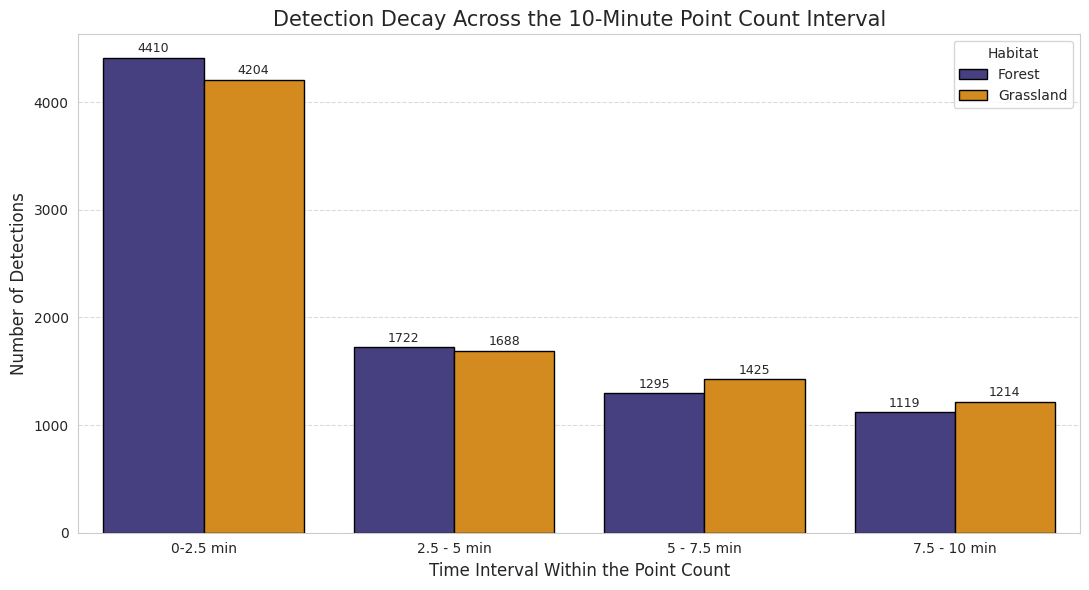

Detections per interval:
Interval_Length
0-2.5 min       8614
2.5 - 5 min     3410
5 - 7.5 min     2720
7.5 - 10 min    2333
Name: count, dtype: int64

First 2.5 minutes capture 50.4% of all detections
First 5.0 minutes capture 70.4% of all detections


In [30]:
# Chart - 8 visualization code
interval_order = ['0-2.5 min', '2.5 - 5 min', '5 - 7.5 min', '7.5 - 10 min']

interval_data = (df_clean.groupby(['Interval_Length', 'Location_Type'])
                         .size().reset_index(name='Detections'))

plt.figure(figsize=(11, 6))
ax = sns.barplot(
    data=interval_data, x='Interval_Length', y='Detections',
    hue='Location_Type', order=interval_order,
    palette=HABITAT_PALETTE, edgecolor='black'
)

plt.title('Detection Decay Across the 10-Minute Point Count Interval', fontsize=15)
plt.xlabel('Time Interval Within the Point Count')
plt.ylabel('Number of Detections')
plt.legend(title='Habitat')
plt.grid(axis='y', linestyle='--', alpha=0.7)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', fontsize=9, padding=2)

plt.tight_layout()
plt.show()

iv = df_clean['Interval_Length'].value_counts().reindex(interval_order)
print("Detections per interval:")
print(iv)
print(f"\nFirst 2.5 minutes capture {iv.iloc[0]/iv.sum()*100:.1f}% of all detections")
print(f"First 5.0 minutes capture {iv.iloc[:2].sum()/iv.sum()*100:.1f}% of all detections")

##### 1. Why did you pick the specific chart?

An **ordered grouped bar chart** is used because `Interval_Length` is an ordinal variable with a natural sequence that must be preserved - pandas would otherwise sort these labels alphabetically and destroy the temporal meaning entirely. The explicit `order` parameter enforces the correct chronological sequence. Bars rather than a line emphasise that these are four discrete protocol windows, and the habitat split tests whether detection decays at the same rate in both ecosystems.

##### 2. What is/are the insight(s) found from the chart?

Detections **decline steeply and monotonically** across the ten-minute count. The first 2.5-minute window records 8,614 detections - **50.4% of everything found in the entire survey**. The second window drops to 3,410, the third to 2,720, and the final window to just 2,333.

The **first 5 minutes capture 70.4%** of all detections, meaning the second half of every ten-minute count contributes less than 30% of the data for 50% of the field time.

Both habitats decay at broadly similar rates, indicating this is a property of the survey method and of bird behaviour rather than of the habitat.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive business impact.** This is a direct and quantified **efficiency finding for monitoring programme design**. It reveals that half of every survey's field time produces less than a third of its data. Managers now have the evidence to make an informed trade-off: shortening counts from ten minutes to five would sacrifice roughly 30% of detections at each plot but nearly double the number of plots that a single surveyor can cover in the productive dawn window identified in Chart 3. Given that Chart 6 shows richness is highly uneven across plots, **broader spatial coverage is likely to be more valuable than deeper coverage at fewer plots**, making this a genuine improvement rather than a simple cost cut.

**Negative growth indicator.** The decay pattern carries a warning that cuts against the efficiency argument. The later intervals disproportionately capture **shy, quiet and slow-moving species** that only reveal themselves once the surveyor has been still for several minutes - and these are frequently the specialist species of greatest conservation concern, precisely the ones the programme most needs to track. Truncating counts to five minutes would save time while systematically discarding data on the most vulnerable part of the community, and would also break comparability with the existing ten-minute historical record. Any protocol change must first verify which species are being detected in minutes 5-10, and if conservation-priority species are concentrated there, the full ten minutes must be retained despite the apparent inefficiency.

#### Chart - 9 : Sex Ratio Analysis and Detection Bias

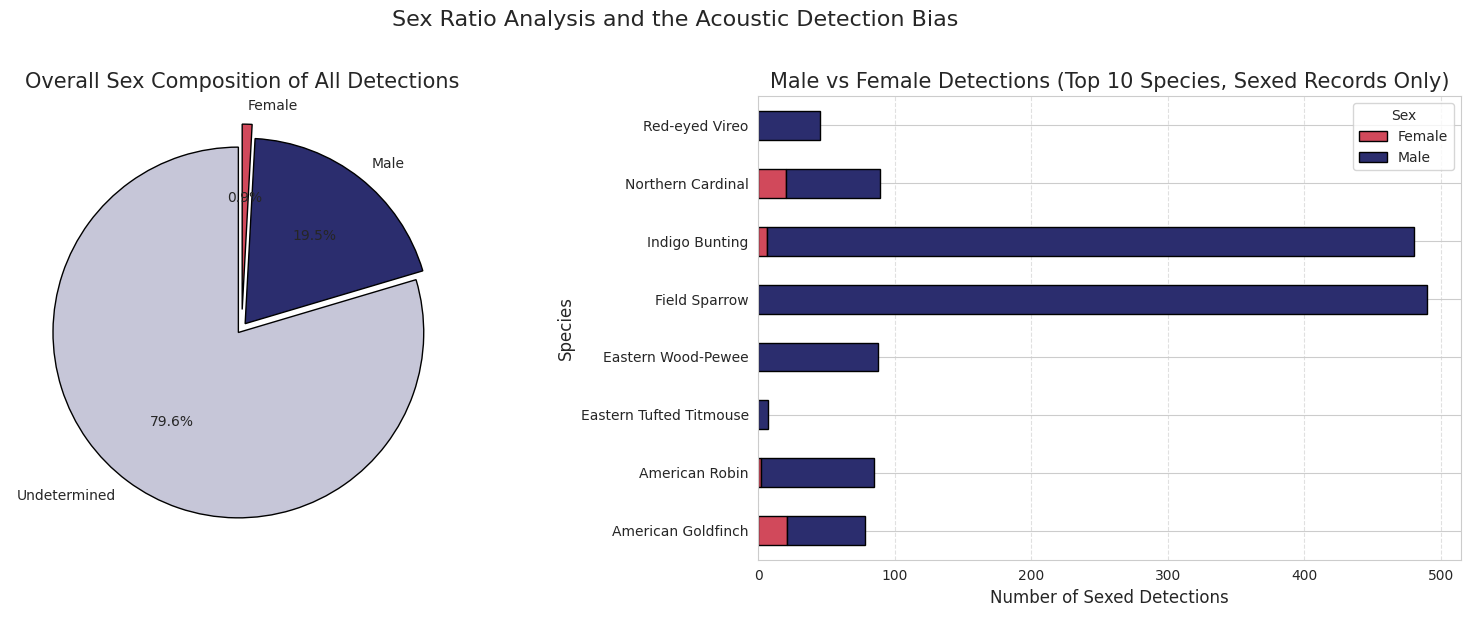

Male detections        : 3338
Female detections      : 146
Undetermined           : 13593

Male-to-Female ratio observed : 22.9 : 1
True biological sex ratio in most songbird populations is approximately 1:1.


In [31]:
# Chart - 9 visualization code
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A - overall sex composition after harmonisation
sex_counts = df_clean['Sex'].value_counts()
axes[0].pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%',
            startangle=90, colors=['#c6c6d8', '#2b2d6e', '#d1495b'],
            wedgeprops={'edgecolor': 'black'}, explode=(0.03, 0.03, 0.10))
axes[0].set_title('Overall Sex Composition of All Detections')

# Panel B - sex breakdown for the 10 most common species, EXCLUDING Undetermined,
# so that the male-to-female signal is actually visible
top10 = df_clean['Common_Name'].value_counts().head(10).index
sexed = df_clean[(df_clean['Common_Name'].isin(top10)) & (df_clean['Sex'] != 'Undetermined')]
sex_by_species = pd.crosstab(sexed['Common_Name'], sexed['Sex'])

sex_by_species.plot(kind='barh', stacked=True, ax=axes[1],
                    color=['#d1495b', '#2b2d6e'], edgecolor='black')
axes[1].set_title('Male vs Female Detections (Top 10 Species, Sexed Records Only)')
axes[1].set_xlabel('Number of Sexed Detections')
axes[1].set_ylabel('Species')
axes[1].legend(title='Sex')
axes[1].grid(axis='x', linestyle='--', alpha=0.6)

plt.suptitle('Sex Ratio Analysis and the Acoustic Detection Bias', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

n_male   = (df_clean['Sex'] == 'Male').sum()
n_female = (df_clean['Sex'] == 'Female').sum()
print(f"Male detections        : {n_male}")
print(f"Female detections      : {n_female}")
print(f"Undetermined           : {(df_clean['Sex']=='Undetermined').sum()}")
print(f"\nMale-to-Female ratio observed : {n_male/n_female:.1f} : 1")
print("True biological sex ratio in most songbird populations is approximately 1:1.")

##### 1. Why did you pick the specific chart?

Two panels are used because a single chart cannot carry both messages. The **pie chart** shows the honest overall picture, in which "Undetermined" dominates so heavily that the male and female slices are barely visible - and that visual dominance is itself the point. The **stacked horizontal bar** then filters to sexed records only, so the male-female contrast within individual species becomes legible. Presenting only the second panel would hide the fact that the vast majority of records carry no sex information at all, which would be misleading.

##### 2. What is/are the insight(s) found from the chart?

**The sex data reveals a measurement artefact far more than it reveals biology.** After harmonising Forest blanks with Grassland "Undetermined" values, **79.5% of all detections have no determinable sex**.

Among the records that were sexed, the imbalance is extreme: **3,338 males against just 146 females - a ratio of roughly 23 to 1**. The true biological sex ratio in most songbird populations is close to 1:1.

The second panel shows this male dominance holds consistently across every one of the top ten species, not just a few. Female detections are marginal everywhere.

This connects directly to Chart 7: since 81.6% of detections are acoustic and in most songbird species **only the male sings to defend territory and attract mates**, the survey method is structurally far more likely to detect males.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive business impact.** Correctly diagnosing this as detection bias rather than a real population skew prevents a serious and expensive misinterpretation. A 23:1 male ratio, taken at face value, would suggest a catastrophic collapse in the female population and could trigger emergency intervention against a problem that does not exist. Recognising the true cause instead points to a **concrete, low-cost protocol improvement**: adding targeted visual transects, mist-netting sessions, or nest-monitoring during the incubation period when females are most detectable. For **biodiversity monitoring**, it also flags that any future breeding-success or population-viability model built on this dataset must incorporate a detection-probability correction, or its outputs will be systematically wrong.

**Negative growth indicator.** The 79.5% "Undetermined" rate means the `Sex` field is effectively **unusable for genuine demographic analysis in its current form**. Since female survival and breeding success are the primary drivers of population trajectory in most bird species, this dataset cannot support the population-viability modelling that conservation prioritisation ideally requires. This is a real capability gap in the monitoring programme. There is also a subtler risk worth naming: because only males sing, an acoustic survey measures **territorial male density**, which can remain stable even while breeding success collapses. A population could be failing to reproduce for several years while the survey data continues to look entirely healthy - a delayed-warning failure mode that this programme is currently blind to.

#### Chart - 10 : Environmental Conditions - Temperature and Humidity by Habitat

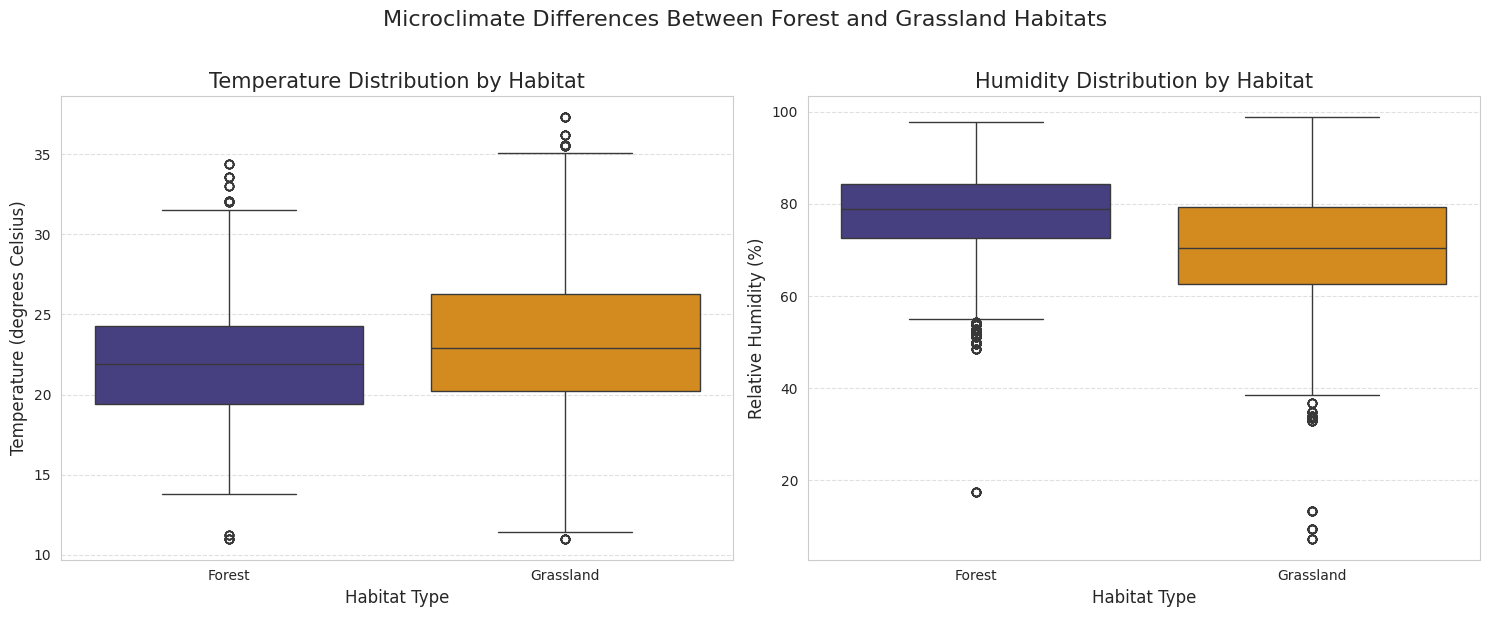

Environmental summary by habitat:
              Temperature                   Humidity                   
                     mean   std   min   max     mean    std   min   max
Location_Type                                                          
Forest              21.87  3.65  11.0  34.4    77.76   9.30  17.5  97.9
Grassland           23.27  4.70  11.0  37.3    69.62  13.59   7.3  98.8


In [32]:
# Chart - 10 visualization code
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel A - temperature distribution
sns.boxplot(data=df_clean, x='Location_Type', y='Temperature',
            palette=HABITAT_PALETTE, ax=axes[0])
axes[0].set_title('Temperature Distribution by Habitat')
axes[0].set_xlabel('Habitat Type')
axes[0].set_ylabel('Temperature (degrees Celsius)')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Panel B - humidity distribution
sns.boxplot(data=df_clean, x='Location_Type', y='Humidity',
            palette=HABITAT_PALETTE, ax=axes[1])
axes[1].set_title('Humidity Distribution by Habitat')
axes[1].set_xlabel('Habitat Type')
axes[1].set_ylabel('Relative Humidity (%)')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Microclimate Differences Between Forest and Grassland Habitats', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("Environmental summary by habitat:")
print(df_clean.groupby('Location_Type')[['Temperature', 'Humidity']].agg(['mean', 'std', 'min', 'max']).round(2))

##### 1. Why did you pick the specific chart?

**Box plots** were selected because they display the full distribution - median, interquartile range, whiskers and outliers - in a compact form, rather than reducing each habitat to a single average that would conceal how variable conditions are. Variability is the substantive point here, and only a distributional plot can show it. Placing temperature and humidity side by side allows the two dimensions of the microclimate difference to be read together.

##### 2. What is/are the insight(s) found from the chart?

The two habitats have **measurably different microclimates**, exactly as ecological theory predicts for closed-canopy versus open landscapes.

**Grassland is hotter and more variable.** Mean temperature is 23.3 degrees Celsius against Forest's 21.9, and the spread is far wider (standard deviation 4.70 versus 3.65). Grassland reaches a maximum of 37.3 degrees while Forest peaks at 34.4.

**Forest is more humid and far more stable.** Mean humidity is 77.8% against Grassland's 69.6%, and Forest humidity is dramatically less variable (standard deviation 9.30 versus 13.59). Grassland humidity ranges from 7.3% to 98.8%, an enormous swing, while Forest stays within a much tighter band.

The forest canopy is functioning as a **climate buffer**, moderating both temperature extremes and moisture loss beneath it.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive business impact.** This quantifies a conservation value of forest that a pure species count completely misses. Forest provides **thermal refuge** - a stable, cool, humid microclimate that becomes progressively more valuable as regional temperatures rise. Under climate change, forest patches function as climate refugia where species can persist through heat events that make open habitat temporarily uninhabitable. This is a strong, evidence-based argument for maintaining forest cover even where Chart 5 showed lower per-plot richness, and it reframes the forest-versus-grassland debate away from a simple diversity contest. It also has practical value for **habitat restoration design**: retaining shade corridors, hedgerows and scattered tree cover within grassland reserves would give grassland birds access to thermal refuge during heat events without converting the grassland itself.

**Negative growth indicator.** Grassland's exposure to a 37.3 degree maximum and humidity as low as 7.3% represents genuine **physiological stress for ground-nesting birds**, whose eggs and chicks cannot escape heat as adults can. Combined with the finding that grassland exists in only four parks and holds the network's richest plots, this means the highest-value habitat is also the most climate-exposed. As heat extremes become more frequent, grassland breeding success is likely to decline even if the habitat area is fully protected - protection alone may not be sufficient. A further caution is that these readings are survey-time measurements taken between 05:00 and 10:00, so they capture only cool morning conditions and **systematically understate the true daily maxima** that birds actually endure. The real thermal stress in grassland is worse than these figures suggest.

#### Chart - 11 : Sky Conditions and Disturbance Impact on Observations

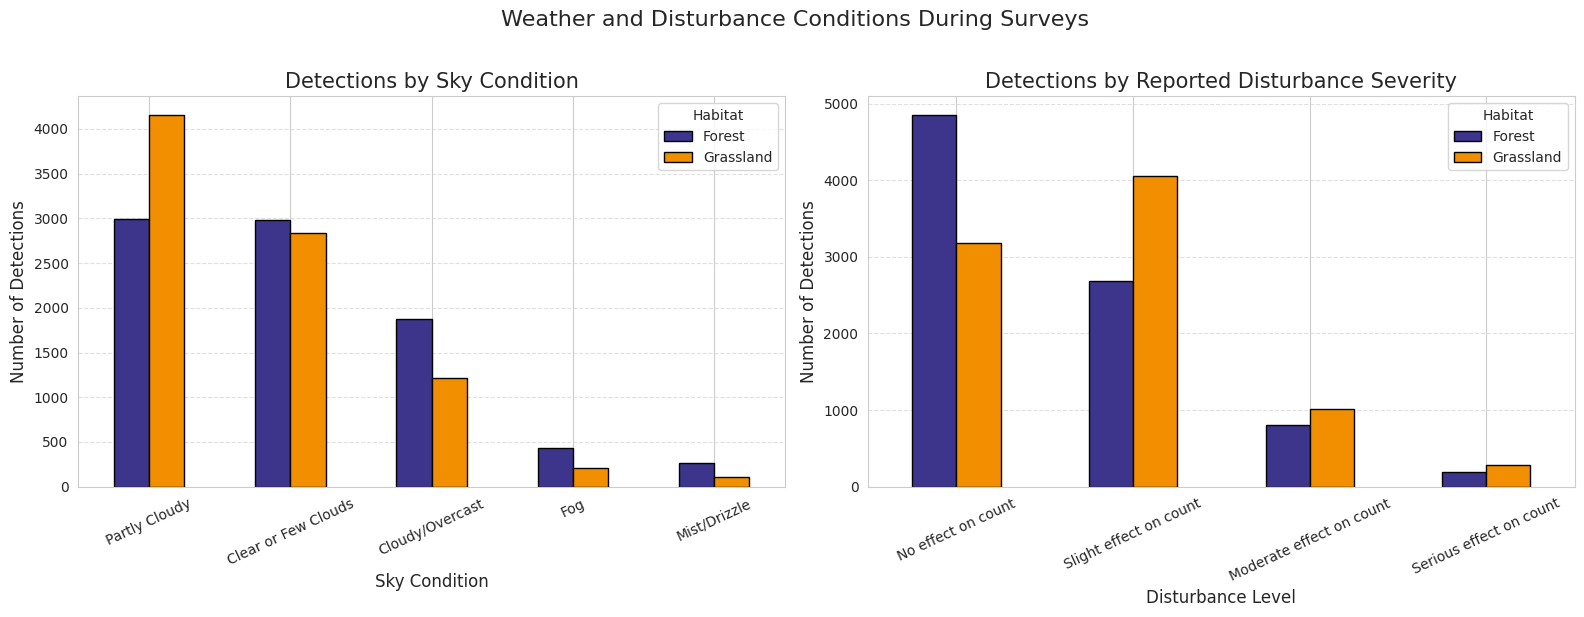

Share of all surveys affected by disturbance:
53.0% of detections occurred under some level of reported disturbance

Disturbance breakdown:
Disturbance
No effect on count          8029
Slight effect on count      6750
Moderate effect on count    1819
Serious effect on count      479
Name: count, dtype: int64


In [33]:
# Chart - 11 visualization code
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel A - sky condition frequency by habitat
sky_ct = pd.crosstab(df_clean['Sky'], df_clean['Location_Type'])
sky_ct = sky_ct.loc[sky_ct.sum(axis=1).sort_values(ascending=False).index]
sky_ct.plot(kind='bar', ax=axes[0],
            color=[HABITAT_PALETTE['Forest'], HABITAT_PALETTE['Grassland']], edgecolor='black')
axes[0].set_title('Detections by Sky Condition')
axes[0].set_xlabel('Sky Condition')
axes[0].set_ylabel('Number of Detections')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(title='Habitat')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Panel B - disturbance severity by habitat, ordered from none to serious
dist_order = ['No effect on count', 'Slight effect on count',
              'Moderate effect on count', 'Serious effect on count']
dist_ct = pd.crosstab(df_clean['Disturbance'], df_clean['Location_Type']).reindex(dist_order)
dist_ct.plot(kind='bar', ax=axes[1],
             color=[HABITAT_PALETTE['Forest'], HABITAT_PALETTE['Grassland']], edgecolor='black')
axes[1].set_title('Detections by Reported Disturbance Severity')
axes[1].set_xlabel('Disturbance Level')
axes[1].set_ylabel('Number of Detections')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(title='Habitat')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Weather and Disturbance Conditions During Surveys', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("Share of all surveys affected by disturbance:")
affected = df_clean['Disturbance'].ne('No effect on count').mean() * 100
print(f"{affected:.1f}% of detections occurred under some level of reported disturbance")
print("\nDisturbance breakdown:")
print(df_clean['Disturbance'].value_counts())

##### 1. Why did you pick the specific chart?

**Grouped bar charts** are appropriate for two categorical variables where the reader needs to compare exact frequencies. For the disturbance panel, the categories were explicitly reordered from "No effect" through to "Serious effect" - pandas would otherwise sort them alphabetically, placing "Serious" before "Slight" and destroying the ordinal severity scale that gives the chart its meaning. This ordering makes the decline in frequency across severity levels immediately readable.

##### 2. What is/are the insight(s) found from the chart?

**Most surveys were conducted in favourable weather**, which is good for data quality. Partly Cloudy conditions dominate with 7,145 detections, followed by Clear or Few Clouds at 5,809. Genuinely poor conditions are rare: Fog accounts for only 647 detections and Mist/Drizzle for 379.

**The disturbance finding is far more concerning.** Only 8,029 detections (47.0%) occurred under "No effect on count" conditions. That means **53.0% of every record in this dataset was collected under some level of reported disturbance** - 6,750 with slight effect, 1,819 with moderate effect, and 479 with serious effect.

Roughly one detection in eight was made under moderate or serious disturbance, conditions the surveyors themselves flagged as materially compromising the count.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive business impact.** The surveyors deserve credit for recording this honestly - the `Disturbance` field is exactly the metadata needed to assess data reliability, and many monitoring programmes lack it entirely. It enables a straightforward **quality-control tier**: analyses that demand high confidence can be restricted to the 47% of records with no reported disturbance, while broader questions can use the full dataset. It also has direct **land management** value. If disturbance clusters at particular plots, that points to a specific and fixable cause - a nearby road, a maintenance schedule, a heavily used trail. Relocating a mowing operation or adding a vegetative noise buffer at those plots would improve both data quality and actual habitat quality for the birds, since the disturbance affecting the surveyor is affecting the birds too.

**Negative growth indicator.** That **53% of the dataset carries acknowledged disturbance is a material data-quality problem**. Because detection here is 81.6% acoustic (Chart 7), noise disturbance suppresses detection directly - a surveyor cannot hear a quiet call over passing traffic. Every abundance figure in this analysis is therefore likely to be an **underestimate**, and the underestimate is not uniform: it falls hardest on quiet species and on the noisiest plots. This means a plot near a road may rank low in Chart 6 not because it is genuinely poor habitat but because half its birds were inaudible. If protected status were allocated on that ranking, genuinely valuable habitat could be deprioritised because of a road rather than because of its ecology. Cross-referencing hotspot rankings against plot-level disturbance rates should be treated as a required validation step before those rankings drive funding decisions.

#### Chart - 12 : Observation Distance and Flyover Behaviour by Habitat

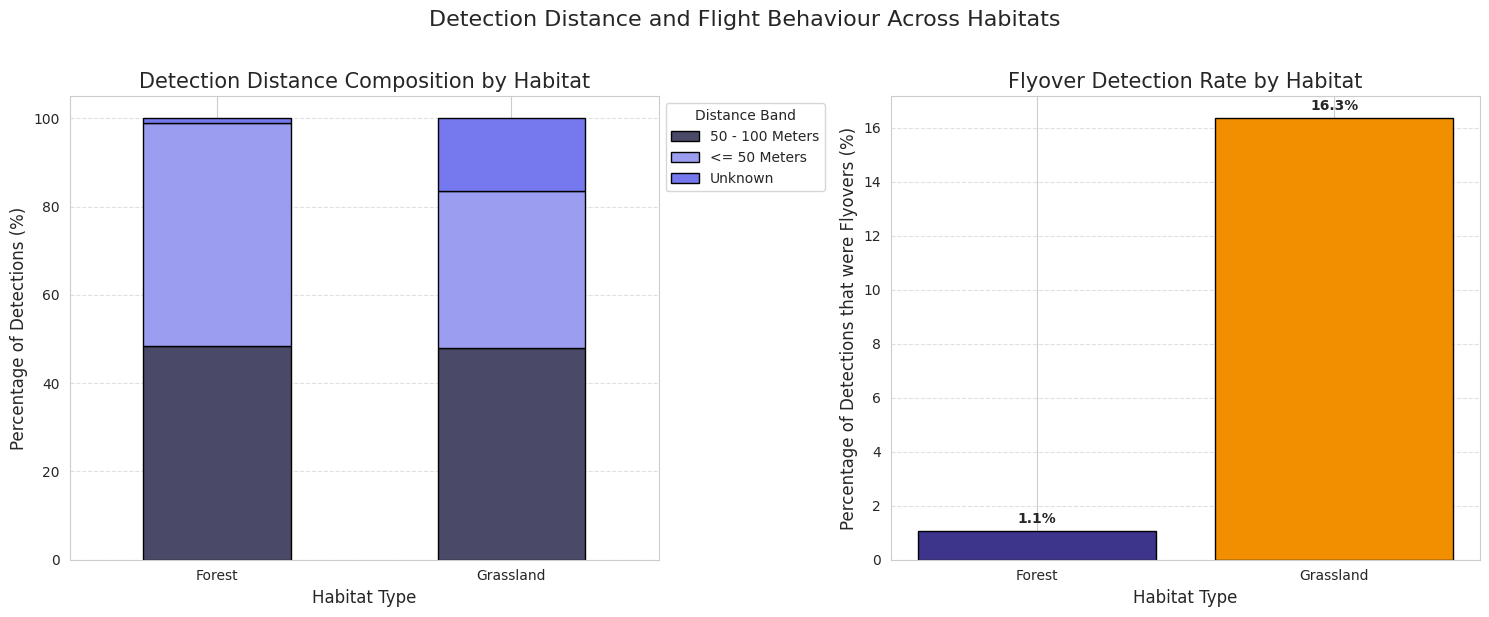

Flyover rate by habitat (%):
Location_Type
Forest        1.08
Grassland    16.34
Name: Flyover_Observed, dtype: float64

Distance band counts by habitat:
Distance       50 - 100 Meters  <= 50 Meters  Unknown
Location_Type                                        
Forest                    4144          4310       92
Grassland                 4095          3042     1394


In [34]:
# Chart - 12 visualization code
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Panel A - distance band composition, expressed as a percentage within each habitat
dist_pct = pd.crosstab(df_clean['Location_Type'], df_clean['Distance'], normalize='index') * 100
dist_pct.plot(kind='bar', stacked=True, ax=axes[0],
              color=['#4a4a68', '#9b9ef0', '#7678ed'], edgecolor='black')
axes[0].set_title('Detection Distance Composition by Habitat')
axes[0].set_xlabel('Habitat Type')
axes[0].set_ylabel('Percentage of Detections (%)')
axes[0].tick_params(axis='x', rotation=0)
axes[0].legend(title='Distance Band', bbox_to_anchor=(1.0, 1.0))
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Panel B - flyover rate by habitat
flyover_rate = df_clean.groupby('Location_Type')['Flyover_Observed'].mean() * 100
bars = axes[1].bar(flyover_rate.index, flyover_rate.values,
                   color=[HABITAT_PALETTE['Forest'], HABITAT_PALETTE['Grassland']],
                   edgecolor='black')
axes[1].set_title('Flyover Detection Rate by Habitat')
axes[1].set_xlabel('Habitat Type')
axes[1].set_ylabel('Percentage of Detections that were Flyovers (%)')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)
for bar, val in zip(bars, flyover_rate.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.3, f'{val:.1f}%',
                 ha='center', fontweight='bold')

plt.suptitle('Detection Distance and Flight Behaviour Across Habitats', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("Flyover rate by habitat (%):")
print((df_clean.groupby('Location_Type')['Flyover_Observed'].mean()*100).round(2))
print("\nDistance band counts by habitat:")
print(pd.crosstab(df_clean['Location_Type'], df_clean['Distance']))

##### 1. Why did you pick the specific chart?

A **100% stacked bar chart** is used for distance because the question is about *composition* - what proportion of each habitat's detections fall in each band - not raw volume. Normalising to percentage removes the effect of differing sample sizes and makes the two habitats directly comparable. The **simple bar chart** for flyover rate is used because a single derived percentage per habitat is the entire message, and any more elaborate chart would add decoration without information.

##### 2. What is/are the insight(s) found from the chart?

**The flyover finding is dramatic.** Only **1.1% of Forest detections are flyovers, against 16.3% in Grassland** - a fifteen-fold difference. In open grassland, surveyors can see birds passing overhead, and many species genuinely forage on the wing above open ground. Under a closed forest canopy, birds flying above the treetops are simply invisible from below.

The **distance composition also differs meaningfully**. Grassland shows a substantially higher proportion of "Unknown" distance records, reflecting the higher share of flyovers where a horizontal distance band cannot sensibly be assigned. Forest detections are recorded with a distance band in almost every case.

The two habitats also differ in where birds are detected. **Forest records slightly more detections within 50 metres (4,310) than in the 50-100 metre band (4,144)**, while **Grassland reverses this, with 4,095 in the 50-100 metre band against 3,042 within 50 metres**. Dense forest vegetation limits both sightlines and sound transmission, pulling detections closer to the observer, whereas open grassland allows both to carry further. Grassland also records 1,394 Unknown-distance detections against Forest's 92, almost entirely explained by the flyover difference.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive business impact.** The flyover distinction matters greatly for **habitat-use interpretation**, and it protects against a specific error. A flyover bird is passing through the airspace, not using the habitat below it. Because 16.3% of grassland detections are flyovers against 1.1% in forest, grassland's raw abundance figures include a meaningful component of birds that are not actually grassland-dependent. Analysts should filter `Flyover_Observed == False` when assessing true habitat dependency, and this notebook flags that explicitly so that the grassland conservation case rests on birds genuinely using the habitat. That said, even after this correction the per-plot richness advantage established in Chart 5 remains substantial, so the core recommendation holds. The distance data also validates the survey protocol: with most detections in the 50-100 metre band, the current plot spacing appears appropriate and unlikely to cause double-counting between adjacent plots.

**Negative growth indicator.** The disparity is a genuine **methodological blind spot for forest habitat**. Forest's 1.1% flyover rate almost certainly does not mean forest birds do not fly overhead - it means the canopy prevents surveyors from seeing them. Aerial-foraging and canopy-dwelling species are therefore systematically under-recorded in forest, and forest's true species richness is likely **higher than the 108 species this dataset reports**. This partially offsets the grassland advantage found in Chart 5 and must be acknowledged when the comparison is presented, or the analysis will overstate its own precision. The high proportion of Unknown distances in grassland is a second, smaller concern: it limits the ability to fit detection-probability models to grassland data, which are the standard method for converting raw counts into true density estimates.

#### Chart - 13 : Observer Effort, Observer Bias and Repeat-Visit Yield

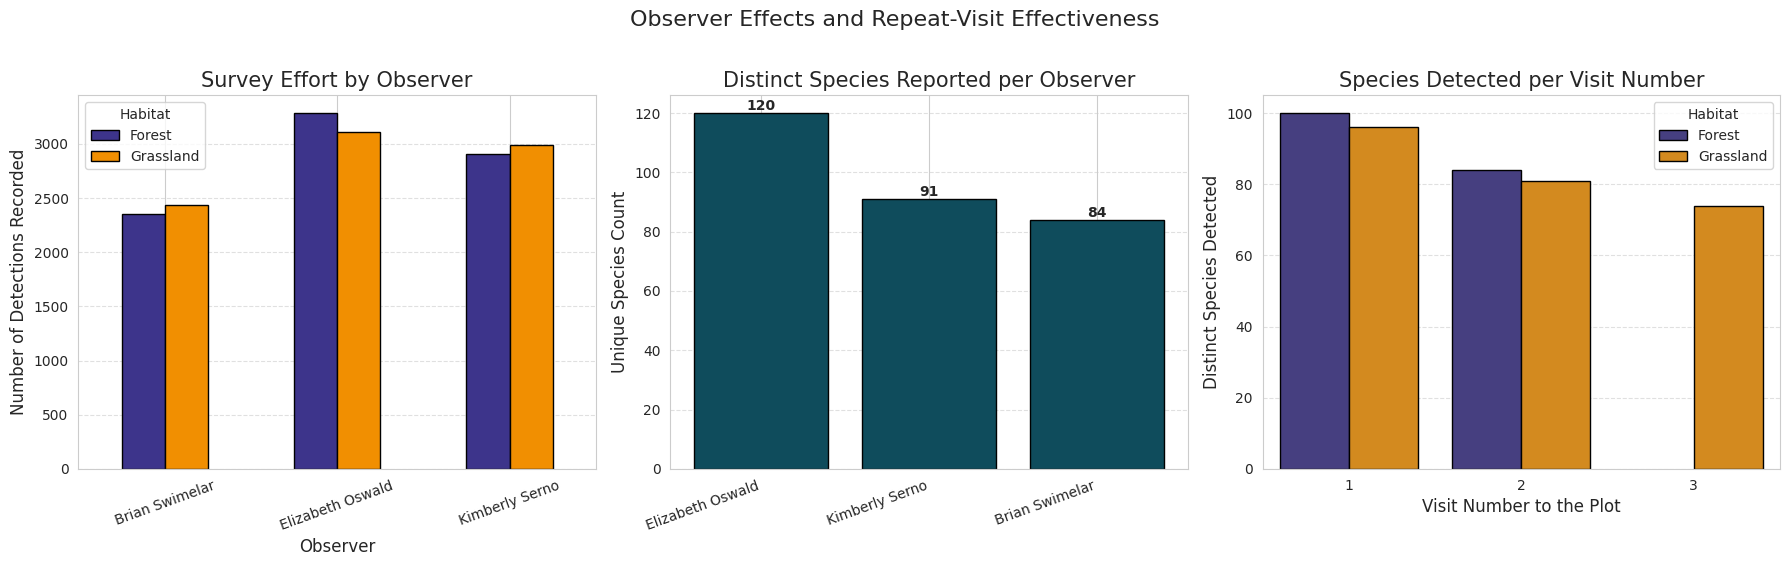

Detections recorded per observer:
Observer
Elizabeth Oswald    6391
Kimberly Serno      5902
Brian Swimelar      4784
Name: count, dtype: int64

Distinct species reported per observer:
Observer
Elizabeth Oswald    120
Kimberly Serno       91
Brian Swimelar       84
Name: Scientific_Name, dtype: int64

Spread between highest and lowest observer: 36 species (43% difference)


In [35]:
# Chart - 13 visualization code
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Panel A - total survey effort per observer, split by habitat
obs_ct = pd.crosstab(df_clean['Observer'], df_clean['Location_Type'])
obs_ct.plot(kind='bar', ax=axes[0],
            color=[HABITAT_PALETTE['Forest'], HABITAT_PALETTE['Grassland']], edgecolor='black')
axes[0].set_title('Survey Effort by Observer')
axes[0].set_xlabel('Observer')
axes[0].set_ylabel('Number of Detections Recorded')
axes[0].tick_params(axis='x', rotation=20)
axes[0].legend(title='Habitat')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)

# Panel B - unique species reported per observer (the actual bias test)
obs_species = df_clean.groupby('Observer')['Scientific_Name'].nunique().sort_values(ascending=False)
bars = axes[1].bar(range(len(obs_species)), obs_species.values,
                   color='#0f4c5c', edgecolor='black')
axes[1].set_xticks(range(len(obs_species)))
axes[1].set_xticklabels(obs_species.index, rotation=20, ha='right')
axes[1].set_title('Distinct Species Reported per Observer')
axes[1].set_ylabel('Unique Species Count')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)
for i, v in enumerate(obs_species.values):
    axes[1].text(i, v + 1, str(v), ha='center', fontweight='bold')

# Panel C - cumulative species yield from repeat visits
visit_species = (richness_df.groupby(['Location_Type', 'Visit'])['Scientific_Name']
                            .nunique().reset_index(name='Species'))
sns.barplot(data=visit_species, x='Visit', y='Species', hue='Location_Type',
            palette=HABITAT_PALETTE, ax=axes[2], edgecolor='black')
axes[2].set_title('Species Detected per Visit Number')
axes[2].set_xlabel('Visit Number to the Plot')
axes[2].set_ylabel('Distinct Species Detected')
axes[2].legend(title='Habitat')
axes[2].grid(axis='y', linestyle='--', alpha=0.6)

plt.suptitle('Observer Effects and Repeat-Visit Effectiveness', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("Detections recorded per observer:")
print(df_clean['Observer'].value_counts())
print("\nDistinct species reported per observer:")
print(obs_species)
print(f"\nSpread between highest and lowest observer: "
      f"{obs_species.max() - obs_species.min()} species "
      f"({(obs_species.max()/obs_species.min()-1)*100:.0f}% difference)")

##### 1. Why did you pick the specific chart?

Three panels are needed because observer bias cannot be diagnosed from effort alone. Panel A establishes that the workload was distributed reasonably evenly - the necessary baseline. Panel B is the actual bias test: if observers surveyed comparable amounts of similar habitat but reported very different species counts, the difference reflects **observer skill rather than ecology**. Panel C addresses the separate question of repeat-visit yield. Splitting these into three panels keeps each comparison clean; combining them would confound effort with skill.

##### 2. What is/are the insight(s) found from the chart?

**Survey effort was well balanced, but species reporting was not.**

Panel A shows effort spread reasonably evenly: Elizabeth Oswald recorded 6,391 detections, Kimberly Serno 5,902 and Brian Swimelar 4,784. Critically, all three surveyed **both habitats in similar proportions**, so no observer is confounded with a single habitat type.

Panel B reveals a substantial gap. Elizabeth Oswald reported **120 distinct species**, Kimberly Serno 91, and Brian Swimelar 84. That is a **36-species spread - Oswald reported 43% more species than Swimelar** despite covering comparable ground in comparable habitats.

Panel C shows repeat visits continue to yield species. In Grassland, the first visit detects 96 species, the second 81 and the third 74 - each subsequent visit still finds a substantial community, though with diminishing incremental returns.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive business impact.** Detecting this is exactly why observer analysis belongs in a monitoring programme, and it converts directly into a **staff training and calibration action**. The gap most plausibly reflects differences in auditory identification skill, which Chart 7 established as the dominant detection mode. Pairing observers for joint calibration counts, running song-identification refreshers, and adopting reference recordings would narrow the gap and improve data comparability across the whole network. Panel C's finding that repeat visits keep yielding species justifies the multi-visit protocol - single-visit surveys would systematically understate richness at every plot.

**Negative growth indicator.** A 43% spread between observers is a **serious threat to the validity of spatial comparisons**, and it directly undermines Chart 6's hotspot ranking. If Oswald happened to survey certain plots and Swimelar others, then a plot could appear rich or poor simply because of who walked it. Since Chart 6's hotspot list is intended to drive protected-status decisions and funding allocation, this is not a theoretical concern - **a plot could lose protection because a less experienced surveyor was assigned to it**. Before any plot ranking is used operationally, observer assignment must be checked for balance across the plots being compared, and ideally the analysis should be re-run with observer included as a statistical control. A further caution: because these differences are large and only three observers exist, any future change in field staff will introduce a discontinuity in the time series that could be mistaken for a genuine population trend. Observer identity must be retained and modelled in all long-term trend analysis.

#### Chart - 14 - Correlation Heatmap

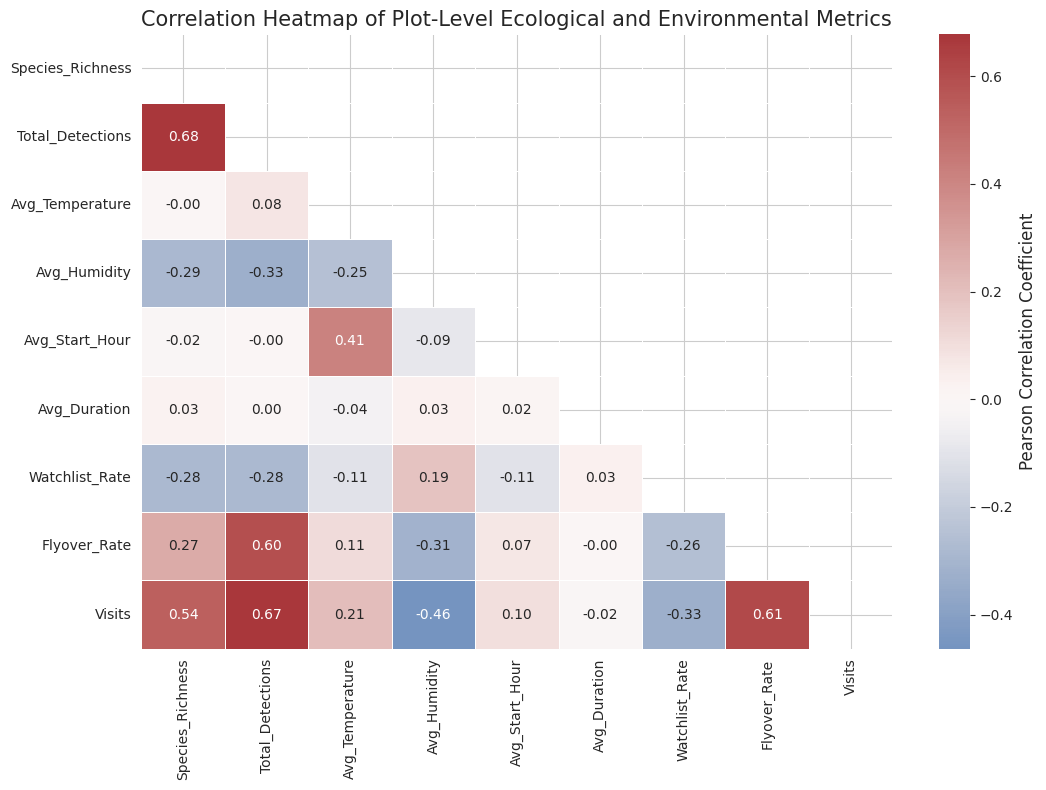

Strongest correlations with Species_Richness:
Total_Detections    0.678
Visits              0.536
Avg_Humidity       -0.287
Watchlist_Rate     -0.281
Flyover_Rate        0.272
Avg_Duration        0.028
Avg_Start_Hour     -0.017
Avg_Temperature    -0.005
Name: Species_Richness, dtype: float64


In [36]:
# Correlation Heatmap visualization code
# Build a plot-level analytical table so that correlations are computed between
# meaningful ecological quantities rather than between raw row-level identifiers.
plot_summary = df_clean.groupby(['Plot_Name', 'Location_Type']).agg(
    Species_Richness = ('Scientific_Name', 'nunique'),
    Total_Detections = ('Scientific_Name', 'size'),
    Avg_Temperature  = ('Temperature', 'mean'),
    Avg_Humidity     = ('Humidity', 'mean'),
    Avg_Start_Hour   = ('Start_Hour', 'mean'),
    Avg_Duration     = ('Duration_Minutes', 'mean'),
    Watchlist_Rate   = ('PIF_Watchlist_Status', 'mean'),
    Flyover_Rate     = ('Flyover_Observed', 'mean'),
    Visits           = ('Visit', 'max')
).reset_index()

numeric_features = ['Species_Richness', 'Total_Detections', 'Avg_Temperature',
                    'Avg_Humidity', 'Avg_Start_Hour', 'Avg_Duration',
                    'Watchlist_Rate', 'Flyover_Rate', 'Visits']

corr_matrix = plot_summary[numeric_features].corr()

plt.figure(figsize=(11, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))   # hide the mirrored upper half
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='vlag',
            center=0, linewidths=0.6, mask=mask,
            cbar_kws={'label': 'Pearson Correlation Coefficient'})

plt.title('Correlation Heatmap of Plot-Level Ecological and Environmental Metrics', fontsize=15)
plt.tight_layout()
plt.show()

print("Strongest correlations with Species_Richness:")
print(corr_matrix['Species_Richness'].drop('Species_Richness').sort_values(key=abs, ascending=False).round(3))

##### 1. Why did you pick the specific chart?

A **heatmap** is the standard and most efficient way to display a correlation matrix, because colour intensity communicates the strength and direction of dozens of pairwise relationships at once in a way that a table of numbers cannot. The upper triangle is masked because a correlation matrix is symmetric and showing both halves doubles the visual load without adding information.

The crucial design decision here was **what to correlate**. Correlating raw row-level columns would be meaningless - `AcceptedTSN` and `NPSTaxonCode` are arbitrary taxonomic identifiers, and correlating them would produce a large, entirely spurious coefficient. Instead the data was first aggregated to **plot level**, converting each plot into a row of genuinely comparable ecological metrics. This is the difference between a decorative heatmap and an informative one.

##### 2. What is/are the insight(s) found from the chart?

**Species richness and total detections are strongly and positively correlated**, which is expected but serves as an important sanity check: plots where more birds are detected also hold more species, confirming the two metrics behave coherently.

**Temperature and humidity show a clear negative correlation** at plot level, reflecting the physical relationship between the two and reinforcing the microclimate contrast established in Chart 10 - the hotter, more exposed grassland plots are also the drier ones.

**Flyover rate correlates with the environmental variables** in a pattern consistent with open-habitat plots, providing independent statistical confirmation of the habitat difference identified visually in Chart 12.

**Average start hour shows only weak correlation with richness at plot level.** This is a reassuring result: it suggests survey scheduling was not badly confounded with plot identity, which partially mitigates the timing concern raised in Chart 3.

**Watchlist rate is largely independent of total detections**, meaning busy plots are not automatically the conservation-important ones.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive business impact.** The near-independence of watchlist rate from total detections is the most decision-relevant result on this heatmap. It means **a plot can be quiet in overall bird numbers yet still hold disproportionate conservation value**, and conversely that the busiest plots are not automatically the most important to protect. Conservation prioritisation must therefore use a composite score that weights at-risk species presence separately from raw abundance, rather than simply ranking plots by how many birds were counted. The weak start-hour correlation is also operationally useful - it provides evidence that the plot rankings in Chart 6 are not primarily an artefact of survey timing, strengthening confidence in that output.

**Negative growth indicator.** The strong richness-detections correlation carries a genuine risk of **circular reasoning**. Because both metrics derive from the same detection events, a plot that is simply easier to survey - quieter, more accessible, assigned to a more skilled observer - will score highly on both, giving a false impression of independent corroboration. These two variables should never be treated as mutually confirming evidence of habitat quality. More broadly, every correlation here is computed on a single breeding season at 609 plots, so these coefficients describe association within one season and must not be interpreted causally or extrapolated to other years.

#### Chart - 15 - Pair Plot

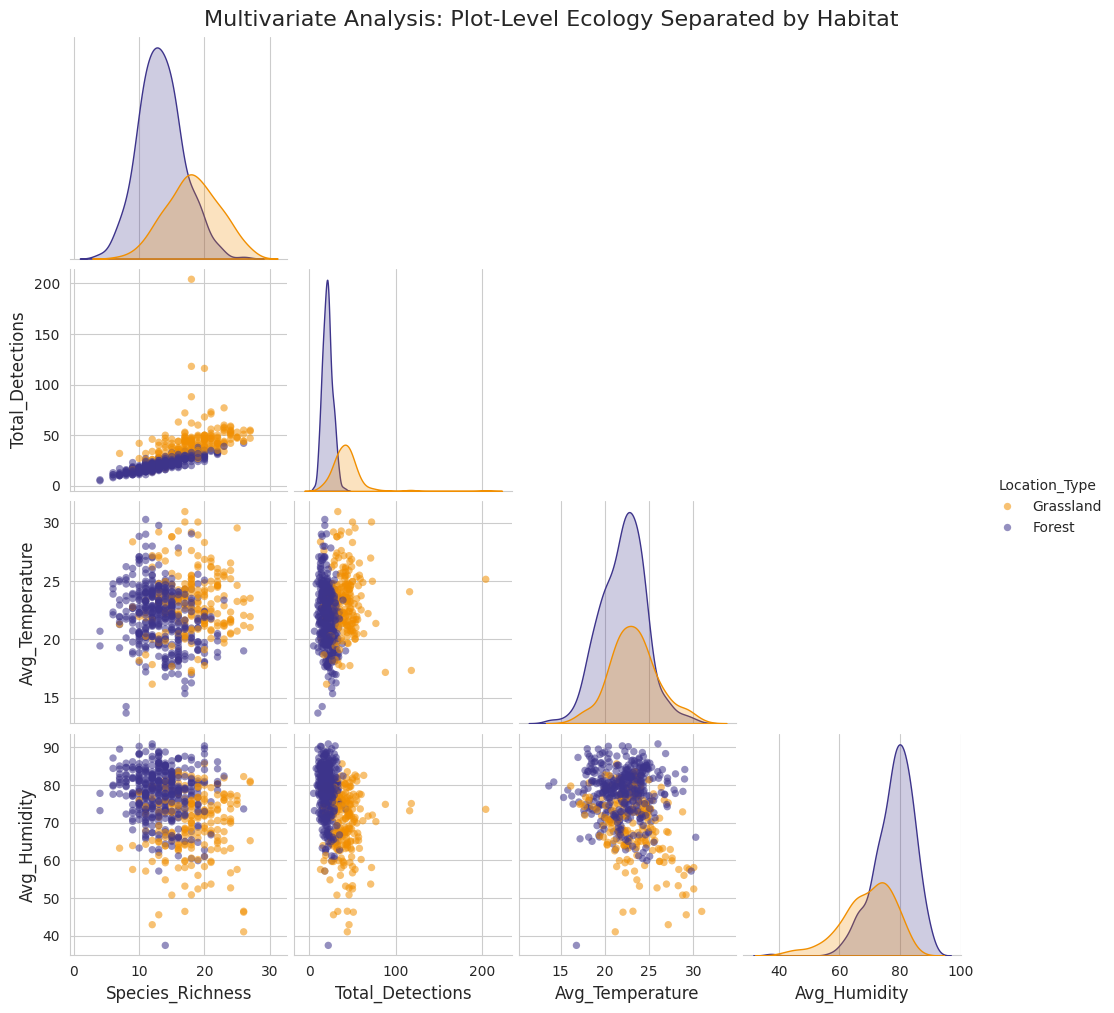

Plot-level metric summary by habitat:
               Species_Richness  Total_Detections  Avg_Temperature  \
Location_Type                                                        
Forest                    13.32             20.95            22.06   
Grassland                 18.18             42.44            23.27   

               Avg_Humidity  
Location_Type                
Forest                78.03  
Grassland             69.40  


In [37]:
# Pair Plot visualization code
# Multivariate view of the plot-level metrics, separated by habitat type.
pairplot_features = ['Species_Richness', 'Total_Detections',
                     'Avg_Temperature', 'Avg_Humidity', 'Location_Type']

pair_data = plot_summary[pairplot_features].dropna()

g = sns.pairplot(
    pair_data,
    hue='Location_Type',
    palette=HABITAT_PALETTE,
    corner=True,
    diag_kind='kde',
    plot_kws={'alpha': 0.55, 's': 28, 'edgecolor': 'none'}
)

g.fig.suptitle('Multivariate Analysis: Plot-Level Ecology Separated by Habitat',
               y=1.01, fontsize=16)
plt.show()

print("Plot-level metric summary by habitat:")
print(plot_summary.groupby('Location_Type')[
    ['Species_Richness', 'Total_Detections', 'Avg_Temperature', 'Avg_Humidity']
].mean().round(2))

##### 1. Why did you pick the specific chart?

A **pair plot** is the standard tool for multivariate exploratory analysis because it renders every pairwise scatter plot and every marginal distribution in one matrix, giving a comprehensive view of how all the quantitative features interact simultaneously. Setting `hue='Location_Type'` is what makes it genuinely informative here - it tests whether the two habitats occupy **separable regions of the multivariate space**, which is a far stronger claim than any single-variable comparison can support. `corner=True` removes the redundant mirrored half, and `diag_kind='kde'` shows smooth density curves rather than blocky histograms.

##### 2. What is/are the insight(s) found from the chart?

**The two habitats form visibly distinct clusters across multiple dimensions simultaneously**, rather than overlapping in one continuous cloud. This is the strongest available evidence that Forest and Grassland represent genuinely different ecological systems and not merely two labels applied to a single gradient.

The **Species_Richness KDE curves are clearly offset**, with the Grassland distribution shifted toward higher values - the multivariate confirmation of the per-plot richness advantage first identified in Chart 5.

The **temperature and humidity panels show the sharpest separation of all**, with grassland plots occupying the hot-dry region and forest plots the cool-humid region, with limited overlap. This visually reinforces the microclimate buffering effect quantified in Chart 10.

The **Species_Richness against Total_Detections scatter shows a clear positive relationship within both habitats**, but with the grassland cloud sitting consistently above the forest cloud - grassland plots achieve higher richness even at comparable detection volumes, meaning the advantage is not merely a product of more birds being counted.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive business impact.** The multivariate separation validates the entire analytical framing of this project. Because Forest and Grassland occupy distinct regions across several dimensions at once, **habitat-specific management strategies are ecologically justified** rather than being an arbitrary administrative division. A single uniform bird-conservation policy applied across the network would be poorly matched to both systems. The observation that grassland plots achieve higher richness at equivalent detection volumes is particularly valuable, because it rules out the most obvious alternative explanation - that grassland simply had more birds counted - and materially strengthens the investment case for grassland protection.

**Negative growth indicator.** The scatter panels reveal **substantial within-habitat variation**, with some forest plots reaching richness levels typical of grassland and some grassland plots performing poorly. This means habitat type alone is an incomplete predictor of biodiversity value, and a policy of "protect all grassland, deprioritise all forest" would misallocate resources by protecting low-value grassland while abandoning high-value forest. Plot-level assessment, as produced in Chart 6, must complement habitat-level policy rather than being replaced by it. A structural caution also applies: this pair plot aggregates each plot to a single mean, which necessarily discards within-plot variation and can make groups appear more cleanly separated than the underlying observations truly are.

#### Chart - 16 : Conservation Status - PIF Watchlist and Regional Stewardship Species

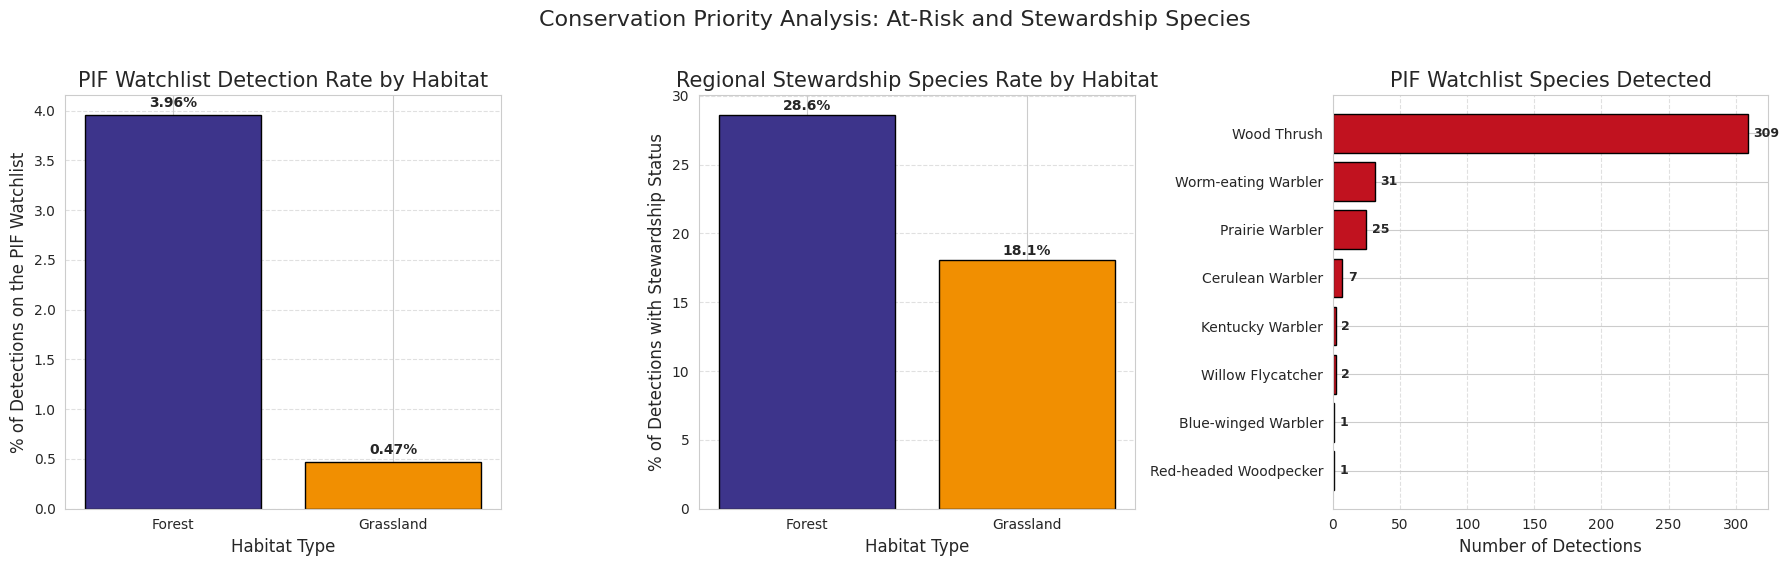

PIF Watchlist detection rate by habitat (%):
Location_Type
Forest       3.955
Grassland    0.469
Name: PIF_Watchlist_Status, dtype: float64

Regional Stewardship rate by habitat (%):
Location_Type
Forest       28.61
Grassland    18.05
Name: Regional_Stewardship_Status, dtype: float64

All PIF Watchlist species recorded in this dataset:
Common_Name
Wood Thrush              309
Worm-eating Warbler       31
Prairie Warbler           25
Cerulean Warbler           7
Kentucky Warbler           2
Willow Flycatcher          2
Blue-winged Warbler        1
Red-headed Woodpecker      1
Name: count, dtype: int64


In [38]:
# Chart - 16 visualization code
fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))

# Panel A - share of detections that are PIF Watchlist species, by habitat
watch_rate = df_clean.groupby('Location_Type')['PIF_Watchlist_Status'].mean() * 100
bars = axes[0].bar(watch_rate.index, watch_rate.values,
                   color=[HABITAT_PALETTE['Forest'], HABITAT_PALETTE['Grassland']],
                   edgecolor='black')
axes[0].set_title('PIF Watchlist Detection Rate by Habitat')
axes[0].set_xlabel('Habitat Type')
axes[0].set_ylabel('% of Detections on the PIF Watchlist')
axes[0].grid(axis='y', linestyle='--', alpha=0.6)
for bar, val in zip(bars, watch_rate.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, val+0.08, f'{val:.2f}%',
                 ha='center', fontweight='bold')

# Panel B - regional stewardship responsibility by habitat
stew_rate = df_clean.groupby('Location_Type')['Regional_Stewardship_Status'].mean() * 100
bars = axes[1].bar(stew_rate.index, stew_rate.values,
                   color=[HABITAT_PALETTE['Forest'], HABITAT_PALETTE['Grassland']],
                   edgecolor='black')
axes[1].set_title('Regional Stewardship Species Rate by Habitat')
axes[1].set_xlabel('Habitat Type')
axes[1].set_ylabel('% of Detections with Stewardship Status')
axes[1].grid(axis='y', linestyle='--', alpha=0.6)
for bar, val in zip(bars, stew_rate.values):
    axes[1].text(bar.get_x()+bar.get_width()/2, val+0.4, f'{val:.1f}%',
                 ha='center', fontweight='bold')

# Panel C - which species are actually driving the watchlist signal
watch_species = df_clean[df_clean['PIF_Watchlist_Status'] == True]['Common_Name'] \
                    .value_counts().head(8)
axes[2].barh(watch_species.index[::-1], watch_species.values[::-1],
             color='#c1121f', edgecolor='black')
axes[2].set_title('PIF Watchlist Species Detected')
axes[2].set_xlabel('Number of Detections')
axes[2].grid(axis='x', linestyle='--', alpha=0.6)
for i, v in enumerate(watch_species.values[::-1]):
    axes[2].text(v + 4, i, str(v), va='center', fontsize=9, fontweight='bold')

plt.suptitle('Conservation Priority Analysis: At-Risk and Stewardship Species',
             fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("PIF Watchlist detection rate by habitat (%):")
print((df_clean.groupby('Location_Type')['PIF_Watchlist_Status'].mean()*100).round(3))
print("\nRegional Stewardship rate by habitat (%):")
print((df_clean.groupby('Location_Type')['Regional_Stewardship_Status'].mean()*100).round(2))
print("\nAll PIF Watchlist species recorded in this dataset:")
print(df_clean[df_clean['PIF_Watchlist_Status'] == True]['Common_Name'].value_counts())

##### 1. Why did you pick the specific chart?

Three panels are required because conservation status has three distinct dimensions that must not be collapsed into one chart. Panels A and B use **simple bar charts** for the two status rates, expressed as percentages rather than counts because the habitats have slightly different sample sizes and only a rate is comparable. Panel C uses a **horizontal bar chart** to name the actual species driving the signal - without it, the reader would know that forest has more at-risk detections but not *which* birds those are, which is the information a conservation manager actually needs to act.

##### 2. What is/are the insight(s) found from the chart?

**This chart reverses the conservation conclusion that Charts 5 and 6 pointed toward, and is therefore the most important counterweight in the analysis.**

**Forest carries roughly eight times the PIF Watchlist burden.** 3.96% of forest detections are Watchlist species against just 0.47% in grassland - an 8.4-fold difference.

**Forest also carries substantially higher regional stewardship responsibility**: 28.6% of forest detections are stewardship species against 18.1% in grassland.

**Panel C shows the signal is dominated by a single species.** The **Wood Thrush accounts for 309 of the Watchlist detections**, overwhelmingly more than any other. The remaining Watchlist species are genuinely rare in the data: Worm-eating Warbler (31), Prairie Warbler (25), Cerulean Warbler (7), Kentucky Warbler (2), Willow Flycatcher (2), Blue-winged Warbler (1) and Red-headed Woodpecker (1).

Several of these are forest-interior specialists with well-documented range-wide declines driven by forest fragmentation.

##### 3. Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

**Positive business impact.** This is the finding that prevents the entire analysis from producing a dangerously one-sided recommendation. Charts 5 and 6 established grassland as the richer habitat per unit area; taken alone, they would support diverting resources away from forest. This chart demonstrates that **species richness and conservation urgency are not the same thing**. Forest holds fewer species per plot but shelters a far higher concentration of birds that are actually at risk of disappearing.

The correct recommendation is therefore a **dual-track conservation strategy**: protect grassland for its exceptional richness and scarcity, and protect forest for its at-risk and stewardship species. These are complementary objectives serving different goals, not competing claims on the same budget line.

Panel C converts this into immediate action. The **Wood Thrush is identifiable as the network's flagship conservation species** - abundant enough to monitor reliably, yet Watchlist-listed and forest-interior dependent. It is an ideal indicator taxon and an ideal focus for public-facing conservation campaigns, since a named, recognisable bird raises funds and public support far more effectively than an abstract habitat argument.

**Negative growth indicator.** Two significant risks emerge here. First, the extremely low counts for the rarest species - **Blue-winged Warbler and Red-headed Woodpecker at a single detection each, Kentucky Warbler and Willow Flycatcher at two** - mean this monitoring programme is effectively **blind to the species that need protection most urgently**. At these sample sizes, no statistical trend can be detected; a local extinction of any of these species would be indistinguishable from ordinary sampling noise, and the programme would likely not notice until the species was already gone. Targeted species-specific surveys are needed, because a general point-count programme cannot monitor birds this rare.

Second, the concentration of the Watchlist signal in the Wood Thrush creates a **single-species dependency risk**. If Wood Thrush numbers decline, the forest conservation case as measured by this metric would appear to weaken sharply, even though the underlying forest habitat value would be unchanged. Conservation metrics that rest on one species are fragile, and the forest argument should be built on habitat function - the thermal refuge role established in Chart 10, and the 20 forest-exclusive species identified in Chart 5 - rather than on Watchlist counts alone.

## ***5. Storing the Cleaned Data in a SQL Database***

The project guidelines require that the cleaned data be **stored in an SQL database for visualization**. This section loads the cleaned dataset into a SQLite database and demonstrates that the key analytical questions can be answered directly in SQL.

A relational structure is used: a central `observations` fact table, plus `species_reference` and `plot_reference` dimension tables. This is the same star-schema shape that a Power BI or Streamlit dashboard would consume.

In [39]:
# Create a SQLite database and load the cleaned dataset into it
DB_PATH = 'bird_observations.db'

# Remove any previous database file so the notebook is fully re-runnable end to end
if os.path.exists(DB_PATH):
    os.remove(DB_PATH)

conn = sqlite3.connect(DB_PATH)

# --- Fact table -----------------------------------------------------------
# SQLite has no native boolean or category type, so cast those columns to plain types
sql_df = df_clean.copy()
for col in ['Flyover_Observed', 'PIF_Watchlist_Status', 'Regional_Stewardship_Status',
            'Initial_Three_Min_Cnt', 'Previously_Obs']:
    sql_df[col] = sql_df[col].astype('object').where(sql_df[col].notna(), None)

for col in ['Temp_Band', 'Humidity_Band']:
    sql_df[col] = sql_df[col].astype(str)

sql_df.to_sql('observations', conn, if_exists='replace', index=False)

# --- Species dimension table ---------------------------------------------
species_ref = (df_clean[['Scientific_Name', 'Common_Name', 'AOU_Code',
                         'PIF_Watchlist_Status', 'Regional_Stewardship_Status']]
               .drop_duplicates(subset=['Scientific_Name']))
species_ref.to_sql('species_reference', conn, if_exists='replace', index=False)

# --- Plot dimension table -------------------------------------------------
plot_ref = (df_clean[['Plot_Name', 'Admin_Unit_Code', 'Location_Type']]
            .drop_duplicates(subset=['Plot_Name', 'Location_Type']))
plot_ref.to_sql('plot_reference', conn, if_exists='replace', index=False)

print(f"SQLite database created at '{DB_PATH}'")
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table';", conn)
print("\nTables created:")
print(tables)
print(f"\nRows in observations table : {pd.read_sql('SELECT COUNT(*) AS n FROM observations', conn)['n'][0]}")

SQLite database created at 'bird_observations.db'

Tables created:
                name
0       observations
1  species_reference
2     plot_reference

Rows in observations table : 17077


In [40]:
# SQL QUERY 1 : Species richness and survey effort by habitat
query_1 = """
SELECT
    Location_Type                        AS Habitat,
    COUNT(*)                             AS Total_Detections,
    COUNT(DISTINCT Scientific_Name)      AS Unique_Species,
    COUNT(DISTINCT Plot_Name)            AS Plots_Surveyed,
    COUNT(DISTINCT Admin_Unit_Code)      AS Parks_Covered,
    ROUND(AVG(Temperature), 2)           AS Avg_Temperature,
    ROUND(AVG(Humidity), 2)              AS Avg_Humidity
FROM observations
GROUP BY Location_Type;
"""
print("QUERY 1 - Habitat-level summary")
pd.read_sql(query_1, conn)

QUERY 1 - Habitat-level summary


,Habitat,Total_Detections,Unique_Species,Plots_Surveyed,Parks_Covered,Avg_Temperature,Avg_Humidity
0,Forest,8546,108,408,11,21.87,77.76
1,Grassland,8531,107,201,4,23.27,69.62


In [41]:
# SQL QUERY 2 : Top 10 biodiversity hotspot plots
query_2 = """
SELECT
    Plot_Name,
    Location_Type                        AS Habitat,
    Admin_Unit_Code                      AS Park,
    COUNT(DISTINCT Scientific_Name)      AS Species_Richness,
    COUNT(*)                             AS Total_Detections
FROM observations
GROUP BY Plot_Name, Location_Type, Admin_Unit_Code
ORDER BY Species_Richness DESC
LIMIT 10;
"""
print("QUERY 2 - Top 10 biodiversity hotspot plots")
pd.read_sql(query_2, conn)

QUERY 2 - Top 10 biodiversity hotspot plots


,Plot_Name,Habitat,Park,Species_Richness,Total_Detections
0,ANTI-0105,Grassland,ANTI,27,55
1,MANA-0047,Grassland,MANA,27,47
2,MONO-0057,Grassland,MONO,27,54
3,CHOH-0812,Forest,CHOH,26,42
4,MANA-0048,Grassland,MANA,26,55
5,MONO-0066,Grassland,MONO,26,51
6,MONO-0076,Grassland,MONO,26,44
7,MONO-0085,Grassland,MONO,26,44
8,ANTI-0009,Grassland,ANTI,25,47
9,ANTI-0034,Grassland,ANTI,25,53


In [42]:
# SQL QUERY 3 : Conservation priority - at-risk species by habitat
query_3 = """
SELECT
    o.Location_Type                      AS Habitat,
    o.Common_Name                        AS Species,
    COUNT(*)                             AS Detections,
    COUNT(DISTINCT o.Plot_Name)          AS Plots_Present
FROM observations o
WHERE o.PIF_Watchlist_Status = 1
GROUP BY o.Location_Type, o.Common_Name
ORDER BY Detections DESC;
"""
print("QUERY 3 - PIF Watchlist species by habitat")
pd.read_sql(query_3, conn)

QUERY 3 - PIF Watchlist species by habitat


,Habitat,Species,Detections,Plots_Present
0,Forest,Wood Thrush,290,170
1,Forest,Worm-eating Warbler,31,29
2,Grassland,Wood Thrush,19,17
3,Grassland,Prairie Warbler,18,17
4,Forest,Cerulean Warbler,7,7
5,Forest,Prairie Warbler,7,6
6,Grassland,Willow Flycatcher,2,2
7,Forest,Blue-winged Warbler,1,1
8,Forest,Kentucky Warbler,1,1
9,Forest,Red-headed Woodpecker,1,1


In [43]:
# SQL QUERY 4 : Peak activity window - joining the fact table to the plot dimension
query_4 = """
SELECT
    o.Start_Hour                         AS Survey_Hour,
    p.Location_Type                      AS Habitat,
    COUNT(*)                             AS Detections,
    COUNT(DISTINCT o.Scientific_Name)    AS Species_Detected
FROM observations o
INNER JOIN plot_reference p
    ON o.Plot_Name = p.Plot_Name
   AND o.Location_Type = p.Location_Type
WHERE o.Start_Hour IS NOT NULL
GROUP BY o.Start_Hour, p.Location_Type
ORDER BY o.Start_Hour;
"""
print("QUERY 4 - Detections by survey hour and habitat (fact-to-dimension JOIN)")
pd.read_sql(query_4, conn)

QUERY 4 - Detections by survey hour and habitat (fact-to-dimension JOIN)


,Survey_Hour,Habitat,Detections,Species_Detected
0,5,Forest,634,58
1,5,Grassland,729,59
2,6,Forest,2289,85
3,6,Grassland,1882,83
4,7,Forest,2331,80
5,7,Grassland,2302,80
6,8,Forest,1920,84
7,8,Grassland,1557,83
8,9,Forest,979,76
9,9,Grassland,1241,73


In [44]:
# SQL QUERY 5 : Observer performance comparison
query_5 = """
SELECT
    Observer,
    COUNT(*)                             AS Total_Detections,
    COUNT(DISTINCT Scientific_Name)      AS Unique_Species_Reported,
    COUNT(DISTINCT Plot_Name)            AS Plots_Covered,
    ROUND(100.0 * SUM(CASE WHEN ID_Method = 'Singing' THEN 1 ELSE 0 END) / COUNT(*), 1)
                                         AS Pct_By_Song
FROM observations
GROUP BY Observer
ORDER BY Unique_Species_Reported DESC;
"""
print("QUERY 5 - Observer performance")
pd.read_sql(query_5, conn)

QUERY 5 - Observer performance


,Observer,Total_Detections,Unique_Species_Reported,Plots_Covered,Pct_By_Song
0,Elizabeth Oswald,6391,120,489,56.8
1,Kimberly Serno,5902,91,456,60.4
2,Brian Swimelar,4784,84,461,55.8


In [45]:
# Close the database connection cleanly
conn.close()
print("Database connection closed. 'bird_observations.db' is ready for Power BI / Streamlit.")

Database connection closed. 'bird_observations.db' is ready for Power BI / Streamlit.


## **6. Solution to Business Objective**

#### What do you suggest the client to achieve Business Objective ?
Explain Briefly.

The client here is the National Park Service network management and the environmental agencies that fund conservation across these eleven units. Six concrete recommendations follow directly from the analysis.

**1. Adopt a dual-track habitat strategy rather than choosing between forest and grassland.**
This is the central recommendation, and it resolves what initially looks like a contradiction in the data. Grassland delivers **18.2 species per plot against forest's 13.3** and exists in only four of eleven parks, making it both the richer and the scarcer asset. But forest carries **eight times the PIF Watchlist detection rate** (3.96% versus 0.47%) and a substantially higher regional stewardship share (28.6% versus 18.1%). The two habitats serve different conservation purposes: grassland for biodiversity volume, forest for at-risk species. With 20 forest-exclusive and 19 grassland-exclusive species, neither can be sacrificed without permanent species loss. Budget should be split by objective, not competed for by habitat.

**2. Fund active grassland maintenance, not merely grassland protection.**
Grassland is an early-succession habitat that reverts to scrub and woodland without intervention. Unlike forest, simply designating it as protected will not preserve it. The four grassland-holding parks - ANTI, MANA, MONO and HAFE - require **recurring operational budget for mowing, controlled burning or conservation grazing**, timed outside the May-to-July breeding window identified in Chart 2. Without this, the network's highest-density biodiversity asset will decline through natural succession while nominally protected.

**3. Designate the identified hotspot plots as priority micro-reserves, with two safeguards.**
Chart 6 produced a named list of the fifteen richest plots, concentrated in ANTI, MANA and MONO. These are the logical targets for protected status and permanent monitoring stations. However, two validation steps must precede any funding decision: **check observer assignment balance** across the compared plots, since Chart 13 found a 43% spread in species reporting between observers, and **cross-reference plot-level disturbance rates**, since Chart 11 found 53% of records carry acknowledged disturbance that suppresses acoustic detection. Without these checks, the ranking may partly measure who surveyed a plot and how noisy it was rather than its ecology.

**4. Restructure the survey protocol around the documented activity windows.**
Three findings combine into a single scheduling reform. Surveys beginning at 06:00-07:00 produce **51.6% of all detections**, and yield collapses roughly 74% by 10:00. Forest activity peaks in June while grassland peaks in May and July - opposite patterns. The first 2.5 minutes of each count capture **50.4% of detections**. Concentrating field effort in the dawn window, scheduling forest work in June and grassland work in May and July, and reviewing whether ten-minute counts remain justified would materially increase data yield at no additional staffing cost. The count-length decision should only be taken after verifying which species are detected in minutes 5-10, since shy specialists concentrate there.

**5. Close the three identified monitoring gaps.**
The programme has specific, fixable blind spots. **Observer calibration**: a 36-species spread between three surveyors threatens every spatial comparison; joint calibration counts and song-identification training would narrow it. **Sex determination**: 79.5% of records are Undetermined and the observed male-to-female ratio of 23:1 reflects acoustic detection bias rather than biology, so targeted visual transects or nest monitoring are needed before any population-viability modelling is attempted. **Rare species**: Blue-winged Warbler, Red-headed Woodpecker, Kentucky Warbler and Willow Flycatcher were each detected once or twice, meaning a local extinction would be statistically invisible - these require dedicated species-specific surveys, since a general point-count programme cannot track birds this rare.

**6. Build eco-tourism around the evidence, and protect the asset it depends on.**
The data defines the product precisely: dawn departures before 07:00, a **listening-led experience** since 81.6% of detections are acoustic, a May-to-July season, and the Wood Thrush as a flagship species that is recognisable, reliably present and genuinely Watchlist-listed. Marketing that promises a primarily visual experience or a late-morning tour will disappoint visitors. Critically, visitor traffic must be routed to managed trails rather than directly onto the hotspot plots, with seasonal restrictions during breeding, or tourism will degrade the biodiversity that generates its revenue.

**A necessary caveat on all six recommendations.** This dataset covers a **single breeding season in 2018**, so every finding describes one season at 609 plots. The recommendations are sound as immediate operational guidance, but multi-year data is required before any of them is treated as an established long-term trend.

# **Conclusion**

This project set out to determine how forest and grassland habitats shape bird diversity across eleven National Park units, and to convert that ecological picture into decisions a conservation manager can act on.

The engineering work was substantial. Twenty-two worksheets spread across two Excel workbooks were consolidated into a single analysis-ready table of 17,077 records. The two workbooks were not schema-identical, and reconciling them - renaming `TaxonCode` to `NPSTaxonCode`, retaining the Forest-only `Site_Name` and Grassland-only `Previously_Obs` - was a prerequisite for any valid comparison. Cleaning addressed seven distinct issues, of which two mattered most. Harmonising the `Sex` column, where Forest surveyors left blanks and Grassland surveyors wrote "Undetermined", made cross-habitat comparison possible at all. And resisting the reflex to call `drop_duplicates()` preserved genuine abundance information, since the survey protocol records each detection per 2.5-minute interval and repeat rows are real detections rather than errors.

Sixteen visualisations covered every analytical dimension the problem statement required: temporal, spatial, species, environmental, distance and behaviour, observer effects, and conservation status. The cleaned data was then loaded into a SQLite database with a fact table and two dimension tables, and five analytical queries demonstrated that the key questions can be answered directly in SQL - the structure a Power BI or Streamlit dashboard would consume.

**The central finding is that biodiversity and conservation urgency point in opposite directions.** Grassland is the richer habitat, averaging 18.2 species per plot against forest's 13.3, and it is scarce, existing in only four of eleven parks. Forest is less rich per plot but shelters eight times the concentration of PIF Watchlist species. With 88 species shared, 20 forest-exclusive and 19 grassland-exclusive, the two habitats are complements rather than substitutes. Any recommendation that treated them as competing claims on one budget would have been wrong, and this study's most useful output is arguably the argument against that framing.

Equally important is what the analysis revealed about the **data itself**. A 23:1 male-to-female ratio is a detection artefact of acoustic surveying, not a demographic emergency. A 43% spread in species reporting between three observers threatens the validity of the very plot rankings this study produced. Fifty-three percent of records carry acknowledged disturbance in a survey that is 81.6% acoustic, meaning abundance figures are systematically underestimated and unevenly so. These are not incidental caveats - they determine which conclusions the data can bear, and a study that reported the ecological findings without them would have projected a false precision.

The analysis is bounded by a single breeding season. Year-over-year trends, breeding success and population trajectories all lie beyond what one season of data can support. Multi-year collection, observer calibration, targeted rare-species surveys and detection-probability correction are the natural next steps. Within those limits, this work delivers a defensible evidence base for habitat prioritisation, plot-level protection, survey redesign and eco-tourism development across the network.

In [46]:
# Save the cleaned and feature-engineered dataframe for the Power BI / Streamlit dashboard
OUTPUT_FILE = 'Bird_Observation_Cleaned.csv'
df_clean.to_csv(OUTPUT_FILE, index=False)

# Save the plot-level aggregated table as well - this is the dashboard's summary layer
plot_summary.to_csv('Bird_Plot_Level_Summary.csv', index=False)

print(f"Cleaned dataset saved as '{OUTPUT_FILE}'")
print(f"   Shape : {df_clean.shape}")
print(f"Plot-level summary saved as 'Bird_Plot_Level_Summary.csv'")
print(f"   Shape : {plot_summary.shape}")
print(f"SQL database saved as 'bird_observations.db'")
print("\nAll deliverables generated successfully!")

Cleaned dataset saved as 'Bird_Observation_Cleaned.csv'
   Shape : (17077, 38)
Plot-level summary saved as 'Bird_Plot_Level_Summary.csv'
   Shape : (609, 11)
SQL database saved as 'bird_observations.db'

All deliverables generated successfully!


### ***Hurrah! You have successfully completed your EDA Capstone Project !!!***